In [53]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Dict, Optional, Tuple

import numpy as np
from scipy.interpolate import RegularGridInterpolator


# ============================================================
# 1. REGIMES
# ============================================================

REGIMES_X_HF = ("X", "HF")


@dataclass(frozen=True)
class RegimeConfig:
    active_modes: Tuple[str, ...] = REGIMES_X_HF

    def __post_init__(self) -> None:
        allowed = {"X", "HF"}
        invalid = [m for m in self.active_modes if m not in allowed]
        if invalid:
            raise ValueError(f"Invalid regimes: {invalid}")
        if len(self.active_modes) == 0:
            raise ValueError("Need at least one active regime.")

    @property
    def mode_to_index(self) -> Dict[str, int]:
        return {m: i for i, m in enumerate(self.active_modes)}

    @property
    def index_to_mode(self) -> Dict[int, str]:
        return {i: m for i, m in enumerate(self.active_modes)}


def feasible_modes(prev_mode: str, cfg: RegimeConfig) -> Tuple[str, ...]:
    """
    In the current X/HF version:
      - X can stay X or become HF
      - HF can stay HF or downscale to X (with salvage handled elsewhere)
    """
    if prev_mode not in cfg.active_modes:
        raise ValueError(f"Unknown prev_mode: {prev_mode}")

    candidates = ("X", "HF")
    out = tuple(m for m in candidates if m in cfg.active_modes)
    if len(out) == 0:
        raise ValueError("No feasible modes available.")
    return out


def kf_allowed_in_mode(mode: str) -> bool:
    if mode not in {"X", "HF"}:
        raise ValueError(f"Unknown mode: {mode}")
    return mode == "HF"


# ============================================================
# 2. PARAMETERS
# ============================================================

@dataclass
class ModelParams:
    # Dynamic
    beta: float = 0.95
    delta: float = 0.10          # depreciation for KH and KF
    delta_M: float = 0.10        # depreciation for M

    # Adjustment costs
    phi_H: float = 0.40
    phi_F: float = 0.40
    phi_M: float = 0.40
    
    phi_T: float = 0.10  

    # Terminal liquidation values
    xi_H: float = 0.40
    xi_F: float = 0.40
    xi_M: float = 0.00           # keep 0.0 if you want "no salvage for M"

    # Marginal investment costs
    q_H: float = 1.0
    q_F: float = 1.0
    q_M: float = 1.0

    # Technology capital switch
    use_M: bool = True

    # CES / reduced-form parameters
    sigma: float = 5.0
    alpha: float = 0.30

    # Demand / cost shifters
    A_H: float = 1.0
    A_F: float = 1.0
    Lambda_H: float = 1.0
    Lambda_F: float = 1.2
    w_H: float = 1.0
    w_F: float = 1.0
    tau_X: float = 1.15

    # Fixed operating costs
    f_H_op: float = 0.03
    f_X_op: float = 0.015
    f_F_op: float = 0.03

    # Sunk switching cost for X -> HF
    f_F_E: float = 0.10
    f_scope: float = 0.05

    eps: float = 1e-10

    @property
    def a(self) -> float:
        return (self.sigma - 1.0) / self.sigma

    @property
    def gamma(self) -> float:
        return 1.0 - self.alpha

    @property
    def mu(self) -> float:
        val = 1.0 - self.a * self.gamma
        if val <= 0:
            raise ValueError("Need mu = 1 - a * gamma > 0.")
        return val

    @property
    def rho(self) -> float:
        return self.a / self.mu

    @property
    def kappa(self) -> float:
        return self.alpha * self.rho
    
    @property
    def nu_M(self) -> float:
        return self.phi_T * self.rho


# ============================================================
# 3. PRODUCTIVITY PROCESSES
# ============================================================

def make_constant_productivity_transition(n_s: int) -> np.ndarray:
    """Deterministic productivity process: s_{t+1} = s_t."""
    return np.eye(n_s)


def fixed_s_process(s_value: float) -> Tuple[np.ndarray, np.ndarray]:
    """One-point productivity grid with constant s over time."""
    if s_value <= 0.0:
        raise ValueError("Need s_value > 0.")
    s_grid = np.array([float(s_value)])
    P = make_constant_productivity_transition(1)
    return s_grid, P


def rouwenhorst(
    n: int,
    rho: float,
    sigma_eps: float,
    mu: float = 0.0,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    if n < 2:
        raise ValueError("n must be at least 2.")
    if abs(rho) >= 1.0:
        raise ValueError("Need |rho| < 1 for a stationary AR(1).")

    prob = (1.0 + rho) / 2.0
    P = np.array([[1.0]])

    for m in range(2, n + 1):
        P_new = np.zeros((m, m))
        P_new[:-1, :-1] += prob * P
        P_new[:-1, 1:] += (1.0 - prob) * P
        P_new[1:, :-1] += (1.0 - prob) * P
        P_new[1:, 1:] += prob * P
        P_new[1:-1, :] /= 2.0
        P = P_new

    sigma_z = sigma_eps / np.sqrt(1.0 - rho**2)
    psi = sigma_z * np.sqrt(n - 1)
    z_grid = np.linspace(-psi, psi, n) + mu
    s_grid = np.exp(z_grid)
    return z_grid, s_grid, P


# ============================================================
# 4. TECHNOLOGY, PROFITS, COSTS
# ============================================================

def investment_cost(i: float, phi: float, q: float) -> float:
    return q * i + 0.5 * phi * i**2


def next_capital(K: float, i: float, delta: float) -> float:
    return (1.0 - delta) * K + i


def tech_multiplier(M: float, p: ModelParams) -> float:
    """
    Static-style choice:
        G(M) = M^nu_M
    """
    if not p.use_M:
        return 1.0
    return max(M, p.eps) ** p.nu_M


def terminal_value(KH: float, KF: float, M: float, p: ModelParams) -> float:
    """
    End-of-horizon liquidation value.
    Keep xi_M = 0.0 if you want no salvage value for M.
    """
    return p.xi_H * KH + p.xi_F * KF + p.xi_M * M


def foreign_capital_salvage(KF: float, p: ModelParams) -> float:
    return p.xi_F * KF


def regime_change_value(
    prev_mode: str,
    new_mode: str,
    KH: float,
    KF: float,
    M: float,
    p: ModelParams,
) -> float:
    """
    Net value adjustment from changing regime.

    Convention:
      - positive = payoff
      - negative = cost

    Current X/HF version:
      X  -> HF : pay sunk cost
      HF -> X  : receive salvage on foreign capital
      same mode: 0
    """
    if prev_mode == new_mode:
        return 0.0

    if prev_mode == "X" and new_mode == "HF":
        return -(p.f_F_E + p.f_scope)

    if prev_mode == "HF" and new_mode == "X":
        return foreign_capital_salvage(KF, p)

    raise ValueError(f"Unsupported regime switch: {prev_mode} -> {new_mode}")


def _safe_power(x: float, power: float, eps: float) -> float:
    return max(x, eps) ** power


def omega_H(p: ModelParams) -> float:
    Rbar_H = p.Lambda_H * ((p.a * p.gamma * p.Lambda_H) / p.w_H) ** (p.a * p.gamma / p.mu)
    return p.mu * Rbar_H * (p.A_H ** p.rho)


def omega_F(p: ModelParams) -> float:
    Rbar_F = p.Lambda_F * ((p.a * p.gamma * p.Lambda_F) / p.w_F) ** (p.a * p.gamma / p.mu)
    return p.mu * Rbar_F * (p.A_F ** p.rho)


def omega_X(p: ModelParams) -> float:
    chi_X = (p.Lambda_F / (p.tau_X * p.Lambda_H)) ** p.sigma
    Xi_X = p.Lambda_H + p.Lambda_F * (chi_X ** p.a)
    w_X_eff = p.w_H * (1.0 + p.tau_X * chi_X) ** (1.0 / p.gamma)
    Rbar_X = Xi_X * ((p.a * p.gamma * Xi_X) / w_X_eff) ** (p.a * p.gamma / p.mu)
    return p.mu * Rbar_X * (p.A_H ** p.rho)


def profit_X(KH: float, M: float, s: float, p: ModelParams) -> float:
    scale = tech_multiplier(M, p) * (s ** p.rho)
    return (
        omega_X(p) * _safe_power(KH, p.kappa, p.eps) * scale
        - p.f_H_op
        - p.f_X_op
    )


def profit_HF(KH: float, KF: float, M: float, s: float, p: ModelParams) -> float:
    scale = tech_multiplier(M, p) * (s ** p.rho)
    home = omega_H(p) * _safe_power(KH, p.kappa, p.eps)
    foreign = omega_F(p) * _safe_power(KF, p.kappa, p.eps)
    return scale * (home + foreign) - p.f_H_op - p.f_F_op


def flow_profit(mode: str, KH: float, KF: float, M: float, s: float, p: ModelParams) -> float:
    if mode == "X":
        return profit_X(KH, M, s, p)
    if mode == "HF":
        return profit_HF(KH, KF, M, s, p)
    raise ValueError(f"Unknown mode: {mode}")


# ============================================================
# 5. INTERPOLATION / EXPECTATIONS
# ============================================================

def _clip(x: float, grid: np.ndarray) -> float:
    return float(np.clip(x, grid[0], grid[-1]))


def nearest_index(grid: np.ndarray, x: float) -> int:
    return int(np.argmin(np.abs(grid - x)))


def local_index_window(center: int, n: int, radius: int) -> np.ndarray:
    lo = max(center - radius, 0)
    hi = min(center + radius, n - 1)
    return np.arange(lo, hi + 1)


def build_value_interpolators(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    M_grid: np.ndarray,
    s_grid: np.ndarray,
    V: np.ndarray,
    cfg: RegimeConfig,
) -> Dict[Tuple[str, int], RegularGridInterpolator]:
    """
    V shape:
        (n_prev_mode, n_KH, n_KF, n_M, n_s)
    """
    interps: Dict[Tuple[str, int], RegularGridInterpolator] = {}

    for pm, prev_mode in enumerate(cfg.active_modes):
        for s_idx in range(len(s_grid)):
            interps[(prev_mode, s_idx)] = RegularGridInterpolator(
                (KH_grid, KF_grid, M_grid),
                V[pm, :, :, :, s_idx],
                bounds_error=False,
                fill_value=None,
            )
    return interps


def make_value_callable(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    M_grid: np.ndarray,
    interps: Dict[Tuple[str, int], RegularGridInterpolator],
) -> Callable[[str, float, float, float, int], float]:
    def value_obj(prev_mode: str, KH: float, KF: float, M: float, s_idx: int) -> float:
        KHc = _clip(KH, KH_grid)
        KFc = _clip(KF, KF_grid)
        Mc = _clip(M, M_grid)
        return float(interps[(prev_mode, s_idx)](np.array([[KHc, KFc, Mc]]))[0])

    return value_obj


def build_expected_grid_from_markov(
    V_next: np.ndarray,
    P: np.ndarray,
    beta: float,
) -> np.ndarray:
    """
    V_next shape:
        (n_prev_mode, n_KH, n_KF, n_M, n_s_next)

    Returns:
        EV shape:
        (n_prev_mode, n_KH, n_KF, n_M, n_s_current)

    with EV[..., s_cur] = beta * E[V_next | s_cur]
    """
    EV = np.empty(V_next.shape[:-1] + (P.shape[0],))

    for pm in range(V_next.shape[0]):
        for s_cur in range(P.shape[0]):
            EV[pm, :, :, :, s_cur] = beta * np.tensordot(
                V_next[pm, :, :, :, :],
                P[s_cur, :],
                axes=([-1], [0]),
            )

    return EV


def build_expected_interpolators(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    M_grid: np.ndarray,
    EV: np.ndarray,
    cfg: RegimeConfig,
) -> Dict[Tuple[str, int], RegularGridInterpolator]:
    """
    EV shape:
        (n_prev_mode, n_KH, n_KF, n_M, n_s_current)
    """
    interps: Dict[Tuple[str, int], RegularGridInterpolator] = {}

    for pm, prev_mode in enumerate(cfg.active_modes):
        for s_idx in range(EV.shape[-1]):
            interps[(prev_mode, s_idx)] = RegularGridInterpolator(
                (KH_grid, KF_grid, M_grid),
                EV[pm, :, :, :, s_idx],
                bounds_error=False,
                fill_value=None,
            )

    return interps


def make_expected_value_callable(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    M_grid: np.ndarray,
    interps: Dict[Tuple[str, int], RegularGridInterpolator],
) -> Callable[[str, float, float, float, int], float]:
    def EV_obj(prev_mode: str, KH: float, KF: float, M: float, s_idx: int) -> float:
        KHc = _clip(KH, KH_grid)
        KFc = _clip(KF, KF_grid)
        Mc = _clip(M, M_grid)
        return float(interps[(prev_mode, s_idx)](np.array([[KHc, KFc, Mc]]))[0])

    return EV_obj

# ============================================================
# 6. FAST TERMINAL-PERIOD SOLVER
# ============================================================

def _require_zero_in_grid(grid: np.ndarray, name: str = "grid", tol: float = 1e-12) -> float:
    idx = nearest_index(grid, 0.0)
    val = float(grid[idx])
    if abs(val) > tol:
        raise ValueError(f"{name} must contain 0.0 exactly (or within tol).")
    return val


def _terminal_i_star(q: float, phi: float, beta: float, xi: float) -> float:
    """
    Solve:
        max_{i >= 0}  - q i - 0.5 phi i^2 + beta * xi * i
    """
    if phi > 0.0:
        return max((beta * xi - q) / phi, 0.0)

    # phi == 0
    if q >= beta * xi:
        return 0.0

    raise ValueError("Terminal problem is unbounded when phi=0 and q < beta*xi.")


def solve_terminal_branch(
    mode: str,
    prev_mode: str,
    KH: float,
    KF: float,
    M: float,
    s: float,
    p: ModelParams,
) -> Dict[str, float]:
    """
    Last decision period:
      - current profits depend on current states (KH, KF, M)
      - investments affect only terminal liquidation value through next-period stocks

    If mode == X:
      - KF_next is forced to 0
      - no iF investment
      - if prev_mode == HF, foreign capital is salvaged immediately
    """
    if mode not in feasible_modes(prev_mode, RegimeConfig(active_modes=("X", "HF"))):
        raise ValueError(f"Infeasible mode transition: {prev_mode} -> {mode}")

    pi = flow_profit(mode, KH, KF, M, s, p)
    regime_adj = regime_change_value(prev_mode, mode, KH, KF, M, p)

    # Home capital
    iH = _terminal_i_star(p.q_H, p.phi_H, p.beta, p.xi_H)
    KH_next = next_capital(KH, iH, p.delta)

    # Technology capital
    iM = _terminal_i_star(p.q_M, p.phi_M, p.beta, p.xi_M)
    M_next = next_capital(M, iM, p.delta_M)

    # Foreign capital
    if mode == "HF":
        iF = _terminal_i_star(p.q_F, p.phi_F, p.beta, p.xi_F)
        KF_next = next_capital(KF, iF, p.delta)
    elif mode == "X":
        iF = 0.0
        KF_next = 0.0
    else:
        raise ValueError(f"Unknown mode: {mode}")

    adjust = (
        investment_cost(iH, p.phi_H, p.q_H)
        + investment_cost(iF, p.phi_F, p.q_F)
        + investment_cost(iM, p.phi_M, p.q_M)
    )
    cont = p.beta * terminal_value(KH_next, KF_next, M_next, p)

    return {
        "mode": mode,
        "value": pi + regime_adj - adjust + cont,
        "profit": pi,
        "regime_change": regime_adj,
        "iH": iH,
        "iF": iF,
        "iM": iM,
        "KH_next": KH_next,
        "KF_next": KF_next,
        "M_next": M_next,
        "continuation": cont,
    }


def solve_terminal_period_grid(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    M_grid: np.ndarray,
    s_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
) -> Dict[str, object]:
    _require_zero_in_grid(KF_grid, "KF_grid")

    n_prev = len(cfg.active_modes)
    n_KH = len(KH_grid)
    n_KF = len(KF_grid)
    n_M = len(M_grid)
    n_s = len(s_grid)

    V = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    policy_mode = np.empty((n_prev, n_KH, n_KF, n_M, n_s), dtype=int)
    iH_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    iF_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    iM_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    KH_next_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    KF_next_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    M_next_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))

    for pm, prev_mode in enumerate(cfg.active_modes):
        feasible = feasible_modes(prev_mode, cfg)

        for i, KH in enumerate(KH_grid):
            for j, KF in enumerate(KF_grid):
                for m_idx, M in enumerate(M_grid):
                    for k, s in enumerate(s_grid):
                        branches = {
                            mode: solve_terminal_branch(
                                mode=mode,
                                prev_mode=prev_mode,
                                KH=float(KH),
                                KF=float(KF),
                                M=float(M),
                                s=float(s),
                                p=p,
                            )
                            for mode in feasible
                        }

                        best_mode = max(feasible, key=lambda m: branches[m]["value"])
                        best = branches[best_mode]

                        V[pm, i, j, m_idx, k] = best["value"]
                        policy_mode[pm, i, j, m_idx, k] = cfg.mode_to_index[best_mode]
                        iH_star[pm, i, j, m_idx, k] = best["iH"]
                        iF_star[pm, i, j, m_idx, k] = best["iF"]
                        iM_star[pm, i, j, m_idx, k] = best["iM"]
                        KH_next_star[pm, i, j, m_idx, k] = best["KH_next"]
                        KF_next_star[pm, i, j, m_idx, k] = best["KF_next"]
                        M_next_star[pm, i, j, m_idx, k] = best["M_next"]

    interps = build_value_interpolators(KH_grid, KF_grid, M_grid, s_grid, V, cfg)
    value_obj = make_value_callable(KH_grid, KF_grid, M_grid, interps)

    return {
        "V": V,
        "policy_mode": policy_mode,
        "iH_star": iH_star,
        "iF_star": iF_star,
        "iM_star": iM_star,
        "KH_next_star": KH_next_star,
        "KF_next_star": KF_next_star,
        "M_next_star": M_next_star,
        "interpolators": interps,
        "value_callable": value_obj,
    }


# ============================================================
# 7. FAST PRE-TERMINAL SOLVER
# ============================================================

def solve_branch_local_search(
    mode: str,
    prev_mode: str,
    KH: float,
    KF: float,
    M: float,
    s_idx: int,
    s_grid: np.ndarray,
    EV_obj: Callable[[str, float, float, float, int], float],
    p: ModelParams,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    M_grid: np.ndarray,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, float]:
    """
    Fast local search over next-period stocks (KH', KF', M').

    Timing:
      - current profits depend on current states
      - chosen investment determines next-period states
      - if mode == X, force KF' = 0
      - if prev_mode == HF and new_mode == X, receive salvage on current KF
    """
    s = float(s_grid[s_idx])
    zero_KF = _require_zero_in_grid(KF_grid, "KF_grid")

    if mode not in feasible_modes(prev_mode, RegimeConfig(active_modes=("X", "HF"))):
        raise ValueError(f"Infeasible mode transition: {prev_mode} -> {mode}")

    pi = flow_profit(mode, KH, KF, M, s, p)
    regime_adj = regime_change_value(prev_mode, mode, KH, KF, M, p)

    center_H = nearest_index(KH_grid, (1.0 - p.delta) * KH)
    center_M = nearest_index(M_grid, (1.0 - p.delta_M) * M)

    if mode == "HF":
        center_F = nearest_index(KF_grid, (1.0 - p.delta) * KF)
    else:
        center_F = nearest_index(KF_grid, zero_KF)

    n_H = len(KH_grid)
    n_F = len(KF_grid)
    n_M = len(M_grid)

    visited = set()
    best: Optional[Dict[str, float]] = None

    for _ in range(max_expansions):
        key = (center_H, center_F, center_M)
        if key in visited:
            break
        visited.add(key)

        idx_H = local_index_window(center_H, n_H, radius)
        idx_M = local_index_window(center_M, n_M, radius)

        if mode == "HF":
            idx_F = local_index_window(center_F, n_F, radius)
        else:
            idx_F = np.array([nearest_index(KF_grid, zero_KF)])

        best_val = -np.inf
        best_idx: Optional[Tuple[int, int, int]] = None
        best_local: Optional[Dict[str, float]] = None

        for iH_idx in idx_H:
            KH_next = float(KH_grid[iH_idx])
            iH = KH_next - (1.0 - p.delta) * KH
            if iH < -1e-12:
                continue

            for iM_idx in idx_M:
                M_next = float(M_grid[iM_idx])
                iM = M_next - (1.0 - p.delta_M) * M
                if iM < -1e-12:
                    continue

                if mode == "X":
                    KF_next = 0.0
                    iF = 0.0

                    adjust = (
                        investment_cost(iH, p.phi_H, p.q_H)
                        + investment_cost(iM, p.phi_M, p.q_M)
                    )
                    EV = EV_obj(mode, KH_next, KF_next, M_next, s_idx)
                    val = pi + regime_adj - adjust + EV

                    if val > best_val:
                        best_val = val
                        best_idx = (iH_idx, idx_F[0], iM_idx)
                        best_local = {
                            "mode": mode,
                            "value": val,
                            "profit": pi,
                            "regime_change": regime_adj,
                            "iH": float(iH),
                            "iF": float(iF),
                            "iM": float(iM),
                            "KH_next": KH_next,
                            "KF_next": KF_next,
                            "M_next": M_next,
                            "EV": EV,
                        }

                elif mode == "HF":
                    for iF_idx in idx_F:
                        KF_next = float(KF_grid[iF_idx])
                        iF = KF_next - (1.0 - p.delta) * KF
                        if iF < -1e-12:
                            continue

                        adjust = (
                            investment_cost(iH, p.phi_H, p.q_H)
                            + investment_cost(iF, p.phi_F, p.q_F)
                            + investment_cost(iM, p.phi_M, p.q_M)
                        )
                        EV = EV_obj(mode, KH_next, KF_next, M_next, s_idx)
                        val = pi + regime_adj - adjust + EV

                        if val > best_val:
                            best_val = val
                            best_idx = (iH_idx, iF_idx, iM_idx)
                            best_local = {
                                "mode": mode,
                                "value": val,
                                "profit": pi,
                                "regime_change": regime_adj,
                                "iH": float(iH),
                                "iF": float(iF),
                                "iM": float(iM),
                                "KH_next": KH_next,
                                "KF_next": KF_next,
                                "M_next": M_next,
                                "EV": EV,
                            }
                else:
                    raise ValueError(f"Unknown mode: {mode}")

        if best_idx is None or best_local is None:
            raise RuntimeError("Local search failed to find a feasible candidate.")

        best = best_local
        iH_idx, iF_idx, iM_idx = best_idx

        hit_edge_H = ((iH_idx == idx_H[0]) and (iH_idx > 0)) or ((iH_idx == idx_H[-1]) and (iH_idx < n_H - 1))
        hit_edge_M = ((iM_idx == idx_M[0]) and (iM_idx > 0)) or ((iM_idx == idx_M[-1]) and (iM_idx < n_M - 1))

        if mode == "HF":
            hit_edge_F = ((iF_idx == idx_F[0]) and (iF_idx > 0)) or ((iF_idx == idx_F[-1]) and (iF_idx < n_F - 1))
        else:
            hit_edge_F = False

        if hit_edge_H or hit_edge_F or hit_edge_M:
            center_H, center_F, center_M = iH_idx, iF_idx, iM_idx
            continue

        break

    if best is None:
        raise RuntimeError("Local search terminated without a solution.")

    return best


def solve_nonterminal_period_grid(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    M_grid: np.ndarray,
    s_grid: np.ndarray,
    P: np.ndarray,
    next_period_sol: Dict[str, object],
    p: ModelParams,
    cfg: RegimeConfig,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    _require_zero_in_grid(KF_grid, "KF_grid")

    EV_grid = build_expected_grid_from_markov(
        V_next=next_period_sol["V"],
        P=P,
        beta=p.beta,
    )
    EV_interps = build_expected_interpolators(KH_grid, KF_grid, M_grid, EV_grid, cfg)
    EV_obj = make_expected_value_callable(KH_grid, KF_grid, M_grid, EV_interps)

    n_prev = len(cfg.active_modes)
    n_KH = len(KH_grid)
    n_KF = len(KF_grid)
    n_M = len(M_grid)
    n_s = len(s_grid)

    V = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    policy_mode = np.empty((n_prev, n_KH, n_KF, n_M, n_s), dtype=int)
    iH_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    iF_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    iM_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    KH_next_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    KF_next_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    M_next_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))

    for pm, prev_mode in enumerate(cfg.active_modes):
        feasible = feasible_modes(prev_mode, cfg)

        for i, KH in enumerate(KH_grid):
            for j, KF in enumerate(KF_grid):
                for m_idx, M in enumerate(M_grid):
                    for s_idx in range(n_s):
                        branches = {
                            mode: solve_branch_local_search(
                                mode=mode,
                                prev_mode=prev_mode,
                                KH=float(KH),
                                KF=float(KF),
                                M=float(M),
                                s_idx=s_idx,
                                s_grid=s_grid,
                                EV_obj=EV_obj,
                                p=p,
                                KH_grid=KH_grid,
                                KF_grid=KF_grid,
                                M_grid=M_grid,
                                radius=radius,
                                max_expansions=max_expansions,
                            )
                            for mode in feasible
                        }

                        best_mode = max(feasible, key=lambda m: branches[m]["value"])
                        best = branches[best_mode]

                        V[pm, i, j, m_idx, s_idx] = best["value"]
                        policy_mode[pm, i, j, m_idx, s_idx] = cfg.mode_to_index[best_mode]
                        iH_star[pm, i, j, m_idx, s_idx] = best["iH"]
                        iF_star[pm, i, j, m_idx, s_idx] = best["iF"]
                        iM_star[pm, i, j, m_idx, s_idx] = best["iM"]
                        KH_next_star[pm, i, j, m_idx, s_idx] = best["KH_next"]
                        KF_next_star[pm, i, j, m_idx, s_idx] = best["KF_next"]
                        M_next_star[pm, i, j, m_idx, s_idx] = best["M_next"]

    interps = build_value_interpolators(KH_grid, KF_grid, M_grid, s_grid, V, cfg)
    value_obj = make_value_callable(KH_grid, KF_grid, M_grid, interps)

    return {
        "V": V,
        "policy_mode": policy_mode,
        "iH_star": iH_star,
        "iF_star": iF_star,
        "iM_star": iM_star,
        "KH_next_star": KH_next_star,
        "KF_next_star": KF_next_star,
        "M_next_star": M_next_star,
        "interpolators": interps,
        "value_callable": value_obj,
        "expected_grid": EV_grid,
        "expected_interpolators": EV_interps,
        "expected_callable": EV_obj,
    }


# ============================================================
# 8. GENERIC FINITE-HORIZON SOLVER
# ============================================================

def solve_finite_horizon_fast(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    M_grid: np.ndarray,
    s_grid: np.ndarray,
    P: np.ndarray,
    n_periods: int,
    p: ModelParams,
    cfg: RegimeConfig,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    """
    Solve a finite-horizon model with n_periods decision periods.

    Timing:
        t = 0, ..., n_periods - 1   : regime and investment choice
        t = n_periods               : liquidation only

    Current profits use current states.
    Investments chosen at t determine next-period states.
    """
    if n_periods < 1:
        raise ValueError("Need n_periods >= 1.")

    _require_zero_in_grid(KF_grid, "KF_grid")

    period_solutions: list[Optional[Dict[str, object]]] = [None] * n_periods

    period_solutions[-1] = solve_terminal_period_grid(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        M_grid=M_grid,
        s_grid=s_grid,
        p=p,
        cfg=cfg,
    )

    for t in range(n_periods - 2, -1, -1):
        period_solutions[t] = solve_nonterminal_period_grid(
            KH_grid=KH_grid,
            KF_grid=KF_grid,
            M_grid=M_grid,
            s_grid=s_grid,
            P=P,
            next_period_sol=period_solutions[t + 1],
            p=p,
            cfg=cfg,
            radius=radius,
            max_expansions=max_expansions,
        )

    return {
        "KH_grid": KH_grid,
        "KF_grid": KF_grid,
        "M_grid": M_grid,
        "s_grid": s_grid,
        "P": P,
        "n_periods": n_periods,
        "p": p,
        "cfg": cfg,
        "period_solutions": period_solutions,
        "solution_t0": period_solutions[0],
    }


# ============================================================
# 9. FIXED-s SOLVER
# ============================================================

def solve_fixed_s_finite_horizon(
    s_value: float,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    M_grid: np.ndarray,
    n_periods: int,
    p: ModelParams,
    cfg: RegimeConfig,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    s_grid, P = fixed_s_process(s_value)

    bundle = solve_finite_horizon_fast(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        M_grid=M_grid,
        s_grid=s_grid,
        P=P,
        n_periods=n_periods,
        p=p,
        cfg=cfg,
        radius=radius,
        max_expansions=max_expansions,
    )
    bundle["solver_type"] = "fixed_s"
    bundle["s_value"] = float(s_value)
    return bundle


# ============================================================
# 10. STOCHASTIC-s SOLVER
# ============================================================

def solve_stochastic_s_finite_horizon(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    M_grid: np.ndarray,
    s_grid: np.ndarray,
    P: np.ndarray,
    n_periods: int,
    p: ModelParams,
    cfg: RegimeConfig,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    bundle = solve_finite_horizon_fast(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        M_grid=M_grid,
        s_grid=s_grid,
        P=P,
        n_periods=n_periods,
        p=p,
        cfg=cfg,
        radius=radius,
        max_expansions=max_expansions,
    )
    bundle["solver_type"] = "stochastic_s"
    return bundle


def solve_rouwenhorst_finite_horizon(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    M_grid: np.ndarray,
    n_periods: int,
    p: ModelParams,
    cfg: RegimeConfig,
    n_s: int = 11,
    rho: float = 0.90,
    sigma_eps: float = 0.12,
    mu: float = 0.0,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    z_grid, s_grid, P = rouwenhorst(n=n_s, rho=rho, sigma_eps=sigma_eps, mu=mu)

    bundle = solve_stochastic_s_finite_horizon(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        M_grid=M_grid,
        s_grid=s_grid,
        P=P,
        n_periods=n_periods,
        p=p,
        cfg=cfg,
        radius=radius,
        max_expansions=max_expansions,
    )
    bundle["z_grid"] = z_grid
    return bundle


# ============================================================
# 11. POLICY SIMULATION
# ============================================================

def simulate_one_path(
    model_bundle: Dict[str, object],
    KH0: float,
    KF0: float,
    M0: float,
    s0_idx: int,
    initial_prev_mode: str = "X",
    stochastic: bool = True,
    seed: Optional[int] = None,
) -> Dict[str, object]:
    KH_grid = model_bundle["KH_grid"]
    KF_grid = model_bundle["KF_grid"]
    M_grid = model_bundle["M_grid"]
    s_grid = model_bundle["s_grid"]
    P = model_bundle["P"]
    cfg = model_bundle["cfg"]
    n_periods = model_bundle["n_periods"]
    period_solutions = model_bundle["period_solutions"]

    rng = np.random.default_rng(seed)

    KH_path = [float(KH0)]
    KF_path = [float(KF0)]
    M_path = [float(M0)]
    s_idx_path = [int(s0_idx)]
    s_path = [float(s_grid[s0_idx])]
    mode_path: list[str] = []
    iH_path: list[float] = []
    iF_path: list[float] = []
    iM_path: list[float] = []

    prev_mode = initial_prev_mode

    for t in range(n_periods):
        sol_t = period_solutions[t]

        i = nearest_index(KH_grid, KH_path[-1])
        j = nearest_index(KF_grid, KF_path[-1])
        m_idx = nearest_index(M_grid, M_path[-1])
        k = s_idx_path[-1]
        pm = cfg.mode_to_index[prev_mode]

        mode = cfg.index_to_mode[int(sol_t["policy_mode"][pm, i, j, m_idx, k])]
        iH = float(sol_t["iH_star"][pm, i, j, m_idx, k])
        iF = float(sol_t["iF_star"][pm, i, j, m_idx, k])
        iM = float(sol_t["iM_star"][pm, i, j, m_idx, k])
        KH_next = float(sol_t["KH_next_star"][pm, i, j, m_idx, k])
        KF_next = float(sol_t["KF_next_star"][pm, i, j, m_idx, k])
        M_next = float(sol_t["M_next_star"][pm, i, j, m_idx, k])

        mode_path.append(mode)
        iH_path.append(iH)
        iF_path.append(iF)
        iM_path.append(iM)

        KH_path.append(KH_next)
        KF_path.append(KF_next)
        M_path.append(M_next)

        if t < n_periods - 1:
            if stochastic:
                k_next = int(rng.choice(np.arange(len(s_grid)), p=P[k, :]))
            else:
                k_next = k
            s_idx_path.append(k_next)
            s_path.append(float(s_grid[k_next]))

        prev_mode = mode

    return {
        "KH_path": KH_path,
        "KF_path": KF_path,
        "M_path": M_path,
        "s_idx_path": s_idx_path,
        "s_path": s_path,
        "mode_path": mode_path,
        "iH_path": iH_path,
        "iF_path": iF_path,
        "iM_path": iM_path,
    }


def simulate_many_paths(
    model_bundle: Dict[str, object],
    KH0: float,
    KF0: float,
    M0: float,
    s0_idx: int,
    n_firms: int = 100,
    initial_prev_mode: str = "X",
    stochastic: bool = True,
    seed: int = 123,
) -> list[Dict[str, object]]:
    rng = np.random.default_rng(seed)
    seeds = rng.integers(0, 2**32 - 1, size=n_firms)

    return [
        simulate_one_path(
            model_bundle=model_bundle,
            KH0=KH0,
            KF0=KF0,
            M0=M0,
            s0_idx=s0_idx,
            initial_prev_mode=initial_prev_mode,
            stochastic=stochastic,
            seed=int(seeds[i]),
        )
        for i in range(n_firms)
    ]


# ============================================================
# 12. SMALL PRINTER
# ============================================================

def print_path_summary(path: Dict[str, object], label: str = "path") -> None:
    print(f"\n=== {label} ===")
    print("modes:   ", path["mode_path"])
    print("iH path: ", [round(x, 4) for x in path["iH_path"]])
    print("iF path: ", [round(x, 4) for x in path["iF_path"]])
    print("iM path: ", [round(x, 4) for x in path["iM_path"]])
    print("KH path: ", [round(x, 4) for x in path["KH_path"]])
    print("KF path: ", [round(x, 4) for x in path["KF_path"]])
    print("M path:  ", [round(x, 4) for x in path["M_path"]])
    print("s path:  ", [round(x, 4) for x in path["s_path"]])

In [52]:
cfg = RegimeConfig(active_modes=("X", "HF"))
p = ModelParams()

KH_grid = np.linspace(0.10, 4.0, 20)
KF_grid = np.linspace(0.00, 2.0, 10)
M_grid = np.linspace(0.10, 3.0, 20)

# Fixed-s version
model_fixed = solve_fixed_s_finite_horizon(
    s_value=1.0,
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    n_periods=9,
    p=p,
    cfg=cfg,
)

TypeError: solve_fixed_s_finite_horizon() missing 1 required positional argument: 'M_grid'

In [54]:
cfg = RegimeConfig(active_modes=("X", "HF"))
p = ModelParams()

KH_grid = np.linspace(0.05, 4.0, 15)
KF_grid = np.linspace(0.00, 2.0, 10)
M_grid = np.linspace(0.05, 3.0, 15)

# Stochastic version
z_grid, s_grid, P = rouwenhorst(n=7, rho=0.90, sigma_eps=0.12)

bundle = solve_rouwenhorst_finite_horizon(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    M_grid=M_grid,
    n_periods=9,
    p=p,
    cfg=cfg,
)

from dataclasses import replace


## Wihthout M
1. For 11 prod states

    a.  $50 \times 50$ states takes 32 minutes to solve 

    b. $40 \times 20$ takes 6 minutes

2. For 19 prod states. 

    b. $40 \times 20$ takes 12 minutes

## With M 
1. for 7 prod states 

    a. $(K_H,K_F,M)= (12,12,12)$, takes 80 minutes


In [128]:
# No-friction version
p_no_fric = replace(p, phi_H=0.0, phi_F=0.0)

model_stoch_no_fric = solve_stochastic_s_finite_horizon(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid,
    P=P,
    n_periods=9,
    p=p_no_fric,
    cfg=cfg,
)

# Analysis 

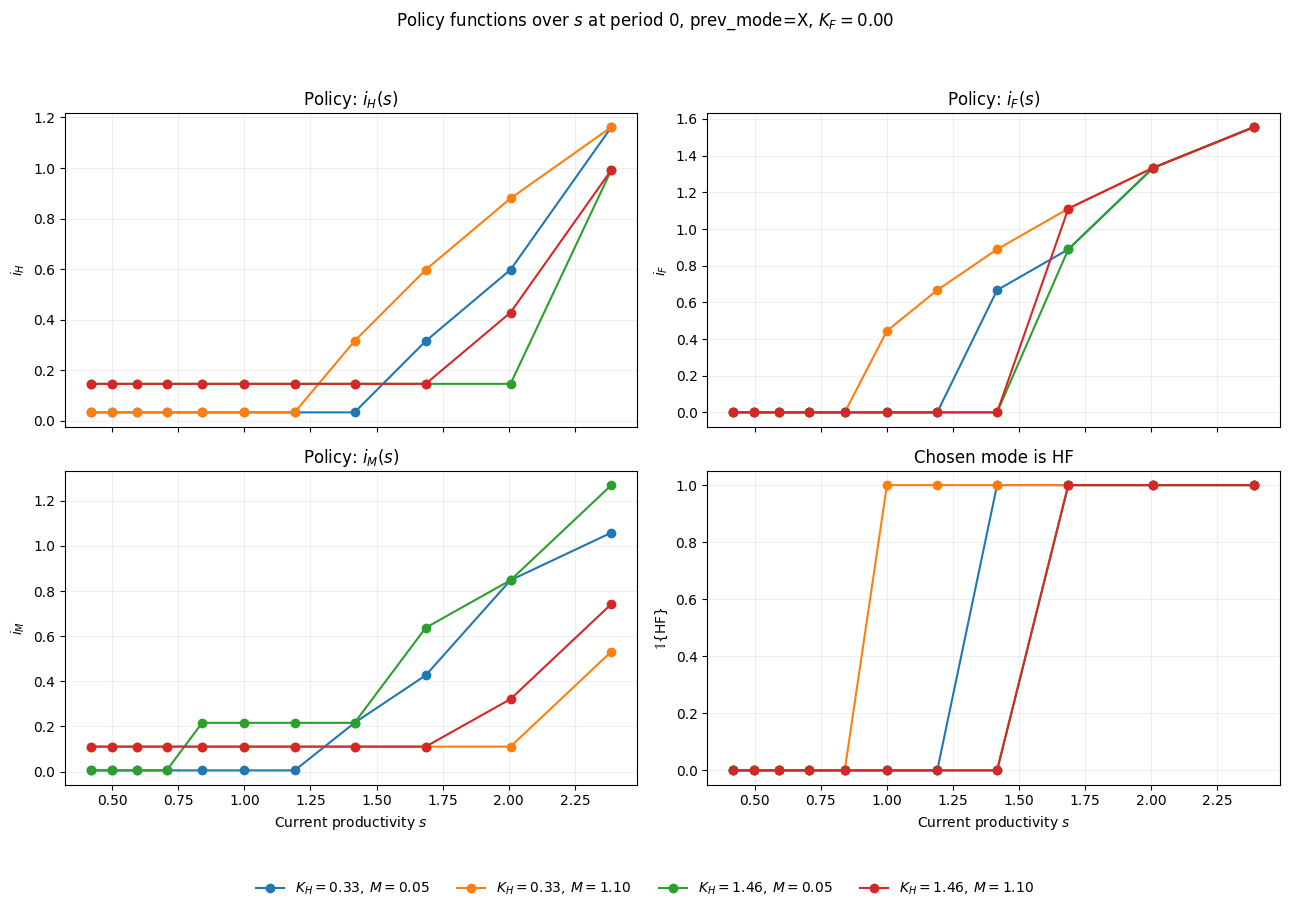

   KH_target   KH_used  KF_used  M_target    M_used                label
0       0.45  0.332143      0.0       0.1  0.050000  $K_H=0.33,\,M=0.05$
1       0.45  0.332143      0.0       1.0  1.103571  $K_H=0.33,\,M=1.10$
2       1.52  1.460714      0.0       0.1  0.050000  $K_H=1.46,\,M=0.05$
3       1.52  1.460714      0.0       1.0  1.103571  $K_H=1.46,\,M=1.10$


In [55]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def _nearest_idx_from_value(grid: np.ndarray, value: float) -> int:
    return int(np.argmin(np.abs(grid - value)))


def plot_policy_functions_over_s(
    model_bundle: Dict[str, object],
    period: int = 0,
    prev_mode: str = "X",
    KH_targets: tuple[float, ...] = (0.5, 1.5),
    M_targets: tuple[float, ...] = (0.1, 1.0),
    KF_target: float = 0.0,
) -> pd.DataFrame:
    """
    Plot policy functions over s for selected (KH, M) combinations.

    For prev_mode="X", use KF_target=0.0.
    For prev_mode="HF", set KF_target to a positive value.

    Returns a small DataFrame describing the selected grid points.
    """
    KH_grid = model_bundle["KH_grid"]
    KF_grid = model_bundle["KF_grid"]
    M_grid = model_bundle["M_grid"]
    s_grid = model_bundle["s_grid"]
    cfg = model_bundle["cfg"]
    sol = model_bundle["period_solutions"][period]

    pm = cfg.mode_to_index[prev_mode]
    j = _nearest_idx_from_value(KF_grid, KF_target)
    chosen_KF = float(KF_grid[j])

    combo_rows = []
    combos = []

    for KH_t in KH_targets:
        i = _nearest_idx_from_value(KH_grid, KH_t)
        for M_t in M_targets:
            m = _nearest_idx_from_value(M_grid, M_t)

            chosen_KH = float(KH_grid[i])
            chosen_M = float(M_grid[m])

            label = fr"$K_H={chosen_KH:.2f},\,M={chosen_M:.2f}$"
            combos.append((i, j, m, label))

            combo_rows.append({
                "KH_target": KH_t,
                "KH_used": chosen_KH,
                "KF_used": chosen_KF,
                "M_target": M_t,
                "M_used": chosen_M,
                "label": label,
            })

    combo_df = pd.DataFrame(combo_rows)

    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)

    for i, j, m, label in combos:
        iH_line = sol["iH_star"][pm, i, j, m, :]
        iF_line = sol["iF_star"][pm, i, j, m, :]
        iM_line = sol["iM_star"][pm, i, j, m, :]
        mode_idx_line = sol["policy_mode"][pm, i, j, m, :]
        hf_line = np.array([1.0 if cfg.index_to_mode[int(x)] == "HF" else 0.0 for x in mode_idx_line])

        axes[0, 0].plot(s_grid, iH_line, marker="o", label=label)
        axes[0, 1].plot(s_grid, iF_line, marker="o", label=label)
        axes[1, 0].plot(s_grid, iM_line, marker="o", label=label)
        axes[1, 1].plot(s_grid, hf_line, marker="o", label=label)

    axes[0, 0].set_title(r"Policy: $i_H(s)$")
    axes[0, 0].set_ylabel(r"$i_H$")

    axes[0, 1].set_title(r"Policy: $i_F(s)$")
    axes[0, 1].set_ylabel(r"$i_F$")

    axes[1, 0].set_title(r"Policy: $i_M(s)$")
    axes[1, 0].set_xlabel(r"Current productivity $s$")
    axes[1, 0].set_ylabel(r"$i_M$")

    axes[1, 1].set_title(r"Chosen mode is HF")
    axes[1, 1].set_xlabel(r"Current productivity $s$")
    axes[1, 1].set_ylabel(r"$\mathbb{1}\{\text{HF}\}$")
    axes[1, 1].set_ylim(-0.05, 1.05)

    for ax in axes.flat:
        ax.grid(alpha=0.2)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.02),
               ncol=min(4, len(labels)), frameon=False)

    fig.suptitle(
        fr"Policy functions over $s$ at period {period}, prev_mode={prev_mode}, $K_F={chosen_KF:.2f}$",
        y=0.98
    )
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

    return combo_df

combo_df_X = plot_policy_functions_over_s(
    model_bundle=bundle,
    period=0,
    prev_mode="X",
    KH_targets=(0.45, 1.52),
    M_targets=(0.10, 1.00),
    KF_target=0.0,
)

print(combo_df_X)

### Step 1: Build inital exporter set

In [6]:
from typing import Dict, Optional
import numpy as np
import pandas as pd

def profit_D_benchmark(KH: float, M: float, s: float, p: ModelParams) -> float:
    scale = tech_multiplier(M, p) * (s ** p.rho)
    return omega_H(p) * _safe_power(KH, p.kappa, p.eps) * scale - p.f_H_op


def collect_initial_exporter_states_multiM(
    model_bundle: Dict[str, object],
    KF0_target: float = 0.0,
    initial_prev_mode: str = "X",
    kh_step: int = 1,
    m_step: int = 1,
    s_idx_subset: Optional[list[int]] = None,
    m_idx_subset: Optional[list[int]] = None,
    require_static_export_premium: bool = True,
    export_premium_tol: float = 0.0,
) -> pd.DataFrame:
    """
    Collect initial exporter states over (KH0, M0, s0), fixing KF0 near KF0_target.
    """
    KH_grid = model_bundle["KH_grid"]
    KF_grid = model_bundle["KF_grid"]
    M_grid = model_bundle["M_grid"]
    s_grid = model_bundle["s_grid"]
    p = model_bundle["p"]
    cfg = model_bundle["cfg"]
    sol_t0 = model_bundle["solution_t0"]

    pm = cfg.mode_to_index[initial_prev_mode]
    x_idx = cfg.mode_to_index["X"]
    j0 = nearest_index(KF_grid, KF0_target)

    if s_idx_subset is None:
        s_idx_subset = list(range(len(s_grid)))
    if m_idx_subset is None:
        m_idx_subset = list(range(0, len(M_grid), m_step))

    rows = []
    for m0 in m_idx_subset:
        for s_idx in s_idx_subset:
            for i in range(0, len(KH_grid), kh_step):
                chosen_mode_idx = int(sol_t0["policy_mode"][pm, i, j0, m0, s_idx])
                if chosen_mode_idx != x_idx:
                    continue

                KH0 = float(KH_grid[i])
                KF0 = float(KF_grid[j0])
                M0 = float(M_grid[m0])
                s0 = float(s_grid[s_idx])

                pi_X = flow_profit("X", KH0, KF0, M0, s0, p)
                pi_D = profit_D_benchmark(KH0, M0, s0, p)
                export_premium = pi_X - pi_D

                if require_static_export_premium and export_premium < export_premium_tol:
                    continue

                rows.append({
                    "state_id": len(rows),
                    "KH0": KH0,
                    "KF0": KF0,
                    "M0": M0,
                    "M0_idx": int(m0),
                    "s0_idx": int(s_idx),
                    "s0": s0,
                    "initial_profit_X": pi_X,
                    "initial_profit_D_benchmark": pi_D,
                    "export_premium": export_premium,
                    "V0_X_region": float(sol_t0["V"][pm, i, j0, m0, s_idx]),
                })

    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df

    return df.sort_values(["M0_idx", "s0_idx", "KH0"]).reset_index(drop=True)

In [97]:
exporter_states_allM = collect_initial_exporter_states_multiM(
    model_bundle=bundle,
    KF0_target=0.0,
    initial_prev_mode="X",
    kh_step=1,
    m_idx_subset=[0, 1, 3, 5, 7],
    require_static_export_premium=False,
)

# -------------------------
# Low M target
# -------------------------
target_M_low = 0.1
available_M = exporter_states_allM[["M0_idx", "M0"]].drop_duplicates().copy()

chosen_row_low = available_M.iloc[(available_M["M0"] - target_M_low).abs().argmin()]
chosen_M_idx_low = int(chosen_row_low["M0_idx"])
chosen_M_val_low = float(chosen_row_low["M0"])

exporter_states_lowM = (
    exporter_states_allM[exporter_states_allM["M0_idx"] == chosen_M_idx_low]
    .copy()
    .reset_index(drop=True)
)

# -------------------------
# High M target
# -------------------------
target_M_high = 1.1
chosen_row_high = available_M.iloc[(available_M["M0"] - target_M_high).abs().argmin()]
chosen_M_idx_high = int(chosen_row_high["M0_idx"])
chosen_M_val_high = float(chosen_row_high["M0"])

exporter_states_highM = (
    exporter_states_allM[exporter_states_allM["M0_idx"] == chosen_M_idx_high]
    .copy()
    .reset_index(drop=True)
)

print("Low M0_idx:", chosen_M_idx_low)
print("Low M0:", chosen_M_val_low)
print("High M0_idx:", chosen_M_idx_high)
print("High M0:", chosen_M_val_high)

Low M0_idx: 0
Low M0: 0.05
High M0_idx: 5
High M0: 1.1035714285714286


### Step 2: Simulate many shock path from each inital state

In [35]:
from typing import Dict
import pandas as pd

def simulate_from_initial_exporter_grid(
    model_bundle: Dict[str, object],
    initial_states: pd.DataFrame,
    N: int = 300,
    stochastic: bool = True,
    initial_prev_mode: str = "X",
    seed: int = 123,
) -> list[dict]:
    """
    For each initial state in `initial_states`, simulate N firms forward.

    Expected columns in initial_states:
        state_id, KH0, KF0, M0, s0_idx, s0
    Optional columns:
        M0_idx, initial_profit_X, export_premium, ...

    Returns a list of dictionaries, one per initial state:
        {
            "state_id": ...,
            "KH0": ...,
            "KF0": ...,
            "M0": ...,
            "s0_idx": ...,
            "s0": ...,
            "paths": [path_1, ..., path_N]
        }
    """
    required_cols = {"state_id", "KH0", "KF0", "M0", "s0_idx", "s0"}
    missing = required_cols - set(initial_states.columns)
    if missing:
        raise ValueError(f"initial_states is missing required columns: {sorted(missing)}")

    out = []

    for row_idx, row in initial_states.iterrows():
        state_seed = seed + 10000 * row_idx

        paths = simulate_many_paths(
            model_bundle=model_bundle,
            KH0=float(row["KH0"]),
            KF0=float(row["KF0"]),
            M0=float(row["M0"]),
            s0_idx=int(row["s0_idx"]),
            n_firms=N,
            initial_prev_mode=initial_prev_mode,
            stochastic=stochastic,
            seed=state_seed,
        )

        result = {
            "state_id": int(row["state_id"]),
            "KH0": float(row["KH0"]),
            "KF0": float(row["KF0"]),
            "M0": float(row["M0"]),
            "s0_idx": int(row["s0_idx"]),
            "s0": float(row["s0"]),
            "paths": paths,
        }

        if "M0_idx" in row.index:
            result["M0_idx"] = int(row["M0_idx"])
        if "initial_profit_X" in row.index:
            result["initial_profit_X"] = float(row["initial_profit_X"])
        if "export_premium" in row.index:
            result["export_premium"] = float(row["export_premium"])

        out.append(result)

    return out

In [99]:
sim_grid_lowM = simulate_from_initial_exporter_grid(
    model_bundle=bundle,
    initial_states=exporter_states_lowM,
    N=300,
    stochastic=True,
    initial_prev_mode="X",
    seed=123,
)

sim_grid_highM = simulate_from_initial_exporter_grid(
    model_bundle=bundle,
    initial_states=exporter_states_highM,
    N=300,
    stochastic=True,
    initial_prev_mode="X",
    seed=456,
)



### Step 3 
for each path, record: 
1. First period when HF is entered
2. Whether ever entered HF
3. Final regime
4. Paths of K_H and K_F

The first block has one row per simulated firm path. The second has one row per firm period

In [37]:
import numpy as np
import pandas as pd

def _first_hf_entry_period(mode_path: list[str]) -> float:
    for t, m in enumerate(mode_path):
        if m == "HF":
            return float(t)
    return np.nan


def _count_mode_switches(mode_path: list[str]) -> int:
    return sum(mode_path[t] != mode_path[t - 1] for t in range(1, len(mode_path)))


def _first_return_to_x_after_hf(mode_path: list[str]) -> float:
    seen_hf = False
    for t, m in enumerate(mode_path):
        if m == "HF":
            seen_hf = True
        elif seen_hf and m == "X":
            return float(t)
    return np.nan


def simulation_grid_to_summary_df(sim_grid: list[dict]) -> pd.DataFrame:
    """
    Convert simulation output into one row per simulated firm-path.
    """
    rows = []

    for state in sim_grid:
        for firm_id, path in enumerate(state["paths"]):
            mode_path = path["mode_path"]
            first_hf = _first_hf_entry_period(mode_path)
            ever_hf = int(any(m == "HF" for m in mode_path))
            stay_x_all_periods = int(all(m == "X" for m in mode_path))
            final_mode = mode_path[-1]

            row = {
                "state_id": state["state_id"],
                "firm_id": firm_id,

                "KH0": float(state["KH0"]),
                "KF0": float(state["KF0"]),
                "M0": float(state["M0"]),
                "s0_idx": int(state["s0_idx"]),
                "s0": float(state["s0"]),

                "ever_hf": ever_hf,
                "stay_x_all_periods": stay_x_all_periods,
                "first_hf_period": first_hf,
                "first_return_to_x_after_hf": _first_return_to_x_after_hf(mode_path),
                "n_mode_switches": _count_mode_switches(mode_path),
                "final_mode": final_mode,
                "final_is_hf": int(final_mode == "HF"),

                "KH_final": float(path["KH_path"][-1]),
                "KF_final": float(path["KF_path"][-1]),
                "M_final": float(path["M_path"][-1]),

                "total_iH": float(np.sum(path["iH_path"])),
                "total_iF": float(np.sum(path["iF_path"])),
                "total_iM": float(np.sum(path["iM_path"])),

                "mean_iH": float(np.mean(path["iH_path"])),
                "mean_iF": float(np.mean(path["iF_path"])),
                "mean_iM": float(np.mean(path["iM_path"])),
            }

            if "M0_idx" in state:
                row["M0_idx"] = int(state["M0_idx"])
            if "initial_profit_X" in state:
                row["initial_profit_X"] = float(state["initial_profit_X"])
            if "export_premium" in state:
                row["export_premium"] = float(state["export_premium"])

            rows.append(row)

    return pd.DataFrame(rows)

In [30]:
import numpy as np
import pandas as pd

def simulation_grid_to_long_df(sim_grid: list[dict]) -> pd.DataFrame:
    """
    Convert simulation output into a long panel:
    one row per firm and decision period t.

    Expected state-level keys:
        state_id, KH0, KF0, M0, s0_idx, s0
    Optional state-level keys:
        M0_idx, initial_profit_X, export_premium

    Expected path-level keys:
        s_path, mode_path, KH_path, KF_path, M_path, iH_path, iF_path, iM_path

    Timing convention:
        - mode_t, s_t, KH_t, KF_t, M_t are period-t states/actions
        - iH_t, iF_t, iM_t are investments chosen at t
        - KH_tp1, KF_tp1, M_tp1 are next-period stocks
    """
    rows = []

    for state in sim_grid:
        for firm_id, path in enumerate(state["paths"]):
            n_periods = len(path["mode_path"])

            for t in range(n_periods):
                mode_t = path["mode_path"][t]
                mode_tm1 = path["mode_path"][t - 1] if t > 0 else np.nan

                row = {
                    "state_id": state["state_id"],
                    "firm_id": firm_id,
                    "t": t,

                    "KH0": float(state["KH0"]),
                    "KF0": float(state["KF0"]),
                    "M0": float(state["M0"]),
                    "s0_idx": int(state["s0_idx"]),
                    "s0": float(state["s0"]),

                    "s_t": float(path["s_path"][t]),
                    "mode_t": mode_t,
                    "mode_tm1": mode_tm1,
                    "is_x_t": int(mode_t == "X"),
                    "is_hf_t": int(mode_t == "HF"),

                    "KH_t": float(path["KH_path"][t]),
                    "KF_t": float(path["KF_path"][t]),
                    "M_t": float(path["M_path"][t]),

                    "iH_t": float(path["iH_path"][t]),
                    "iF_t": float(path["iF_path"][t]),
                    "iM_t": float(path["iM_path"][t]),

                    "KH_tp1": float(path["KH_path"][t + 1]),
                    "KF_tp1": float(path["KF_path"][t + 1]),
                    "M_tp1": float(path["M_path"][t + 1]),

                    "entered_hf_t": int((mode_t == "HF") and (t == 0 or path["mode_path"][t - 1] != "HF")),
                    "exited_hf_t": int((t > 0) and (path["mode_path"][t - 1] == "HF") and (mode_t != "HF")),
                    "switched_mode_t": int((t > 0) and (path["mode_path"][t - 1] != mode_t)),
                }

                if "M0_idx" in state:
                    row["M0_idx"] = int(state["M0_idx"])
                if "initial_profit_X" in state:
                    row["initial_profit_X"] = float(state["initial_profit_X"])
                if "export_premium" in state:
                    row["export_premium"] = float(state["export_premium"])

                rows.append(row)

    return pd.DataFrame(rows)

In [100]:
summary_df_lowM = simulation_grid_to_summary_df(sim_grid_lowM)
long_df_lowM = simulation_grid_to_long_df(sim_grid_lowM)

summary_df_highM = simulation_grid_to_summary_df(sim_grid_highM)
long_df_highM = simulation_grid_to_long_df(sim_grid_highM)

### Step 4: Aggregate
For each $(s_0,K_0)$ compute 

1. HF-entry probability
2. median entry time 
3. probability of remaining in X 
4. average investment path



In [ ]:
import pandas as pd

def aggregate_simulations_by_initial_state(summary_df: pd.DataFrame) -> pd.DataFrame:
    group_cols = ["state_id", "s0_idx", "s0", "KH0", "KF0", "M0"]
    if "M0_idx" in summary_df.columns:
        group_cols.append("M0_idx")
    if "initial_profit_X" in summary_df.columns:
        group_cols.append("initial_profit_X")
    if "export_premium" in summary_df.columns:
        group_cols.append("export_premium")

    agg_dict = {
        "firm_id": "count",
        "ever_hf": "mean",
        "stay_x_all_periods": "mean",
        "final_is_hf": "mean",
        "first_hf_period": ["mean", "median"],
        "KH_final": "mean",
        "KF_final": "mean",
        "M_final": "mean",
        "total_iH": "mean",
        "total_iF": "mean",
        "total_iM": "mean",
        "mean_iH": "mean",
        "mean_iF": "mean",
        "mean_iM": "mean",
    }

    if "first_return_to_x_after_hf" in summary_df.columns:
        agg_dict["first_return_to_x_after_hf"] = "mean"
    if "n_mode_switches" in summary_df.columns:
        agg_dict["n_mode_switches"] = "mean"

    agg = summary_df.groupby(group_cols, as_index=False).agg(agg_dict)

    # flatten column names
    agg.columns = [
        "state_id" if c == ("state_id", "") else
        "s0_idx" if c == ("s0_idx", "") else
        "s0" if c == ("s0", "") else
        "KH0" if c == ("KH0", "") else
        "KF0" if c == ("KF0", "") else
        "M0" if c == ("M0", "") else
        "M0_idx" if c == ("M0_idx", "") else
        "initial_profit_X" if c == ("initial_profit_X", "") else
        "export_premium" if c == ("export_premium", "") else
        "n_paths" if c == ("firm_id", "count") else
        "hf_share_ever" if c == ("ever_hf", "mean") else
        "stay_x_share" if c == ("stay_x_all_periods", "mean") else
        "final_hf_share" if c == ("final_is_hf", "mean") else
        "mean_entry_period" if c == ("first_hf_period", "mean") else
        "median_entry_period" if c == ("first_hf_period", "median") else
        "mean_return_to_x_period" if c == ("first_return_to_x_after_hf", "mean") else
        "mean_n_mode_switches" if c == ("n_mode_switches", "mean") else
        "mean_KH_final" if c == ("KH_final", "mean") else
        "mean_KF_final" if c == ("KF_final", "mean") else
        "mean_M_final" if c == ("M_final", "mean") else
        "mean_total_iH" if c == ("total_iH", "mean") else
        "mean_total_iF" if c == ("total_iF", "mean") else
        "mean_total_iM" if c == ("total_iM", "mean") else
        "mean_iH" if c == ("mean_iH", "mean") else
        "mean_iF" if c == ("mean_iF", "mean") else
        "mean_iM" if c == ("mean_iM", "mean") else
        "_".join([str(x) for x in c if x != ""])
        for c in agg.columns
    ]

    return agg.sort_values(["s0_idx", "KH0", "M0"]).reset_index(drop=True)


def aggregate_by_initial_productivity(agg_state_df: pd.DataFrame) -> pd.DataFrame:
    group_cols = ["s0_idx", "s0"]
    if "M0" in agg_state_df.columns:
        group_cols.append("M0")
    if "M0_idx" in agg_state_df.columns:
        group_cols.append("M0_idx")

    out = (
        agg_state_df
        .groupby(group_cols, as_index=False)
        .agg(
            n_initial_states=("state_id", "count"),
            avg_hf_share_ever=("hf_share_ever", "mean"),
            avg_stay_x_share=("stay_x_share", "mean"),
            avg_final_hf_share=("final_hf_share", "mean"),
            avg_entry_period=("mean_entry_period", "mean"),
            avg_KH_final=("mean_KH_final", "mean"),
            avg_KF_final=("mean_KF_final", "mean"),
            avg_M_final=("mean_M_final", "mean"),
            avg_total_iH=("mean_total_iH", "mean"),
            avg_total_iF=("mean_total_iF", "mean"),
            avg_total_iM=("mean_total_iM", "mean"),
        )
    )

    sort_cols = ["s0_idx"]
    if "M0" in out.columns:
        sort_cols.append("M0")
    return out.sort_values(sort_cols).reset_index(drop=True)

In [101]:
agg_state_df_lowM = aggregate_simulations_by_initial_state(summary_df_lowM)
agg_s_df_lowM = aggregate_by_initial_productivity(agg_state_df_lowM)

agg_state_df_highM = aggregate_simulations_by_initial_state(summary_df_highM)
agg_s_df_highM = aggregate_by_initial_productivity(agg_state_df_highM)

# Figures
the figures displays
1. Heatmap of probabiliyt of becomming a HF at terminal time point 
2. Heatmap of mean period of entering HF
3. Comparison with no investment frictions

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def make_heatmap_matrix(df: pd.DataFrame, value_col: str):
    """
    Build a matrix with:
      rows    = s0
      columns = KH0
      entries = value_col
    """
    pivot = df.pivot(index="s0", columns="KH0", values=value_col)
    pivot = pivot.sort_index(axis=0).sort_index(axis=1)

    y_vals = pivot.index.to_numpy(dtype=float)    # s0
    x_vals = pivot.columns.to_numpy(dtype=float)  # KH0
    Z = pivot.to_numpy(dtype=float)

    return x_vals, y_vals, Z


def centers_to_edges(vals: np.ndarray) -> np.ndarray:
    """
    Convert sorted cell centers into cell edges for pcolormesh.
    Works for non-equally spaced grids.
    """
    vals = np.asarray(vals, dtype=float)
    if len(vals) < 2:
        raise ValueError("Need at least 2 grid points to construct edges.")

    mids = 0.5 * (vals[:-1] + vals[1:])
    first = vals[0] - 0.5 * (vals[1] - vals[0])
    last = vals[-1] + 0.5 * (vals[-1] - vals[-2])
    edges = np.concatenate([[first], mids, [last]])
    return edges


def plot_heatmaps_for_one_M(agg_state_df: pd.DataFrame, fig_title_prefix: str = "") -> None:
    """
    Create one 1x2 figure:
      - HF entry probability
      - mean HF entry period
    for a single M slice.
    """
    if "M0" in agg_state_df.columns and agg_state_df["M0"].nunique() != 1:
        raise ValueError("agg_state_df contains multiple M0 values. Filter to one M slice first.")

    chosen_M = float(agg_state_df["M0"].iloc[0]) if "M0" in agg_state_df.columns else np.nan

    x_vals_prob, y_vals_prob, Z_prob = make_heatmap_matrix(agg_state_df, "hf_share_ever")
    x_vals_time, y_vals_time, Z_time = make_heatmap_matrix(agg_state_df, "mean_entry_period")

    if not (np.allclose(x_vals_prob, x_vals_time) and np.allclose(y_vals_prob, y_vals_time)):
        raise ValueError("Probability and timing matrices are not aligned.")

    Z_time_masked = np.ma.masked_invalid(Z_time)

    x_edges = centers_to_edges(x_vals_prob)
    y_edges = centers_to_edges(y_vals_prob)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    # Left: HF entry probability
    pcm1 = axes[0].pcolormesh(
        x_edges,
        y_edges,
        Z_prob,
        shading="auto"
    )
    axes[0].set_xlabel(r"Initial $K_{H,0}$")
    axes[0].set_ylabel(r"Initial productivity $s_0$")
    axes[0].set_title(fr"{fig_title_prefix}HF entry probability ($M_0={chosen_M:.3f}$)")
    cbar1 = fig.colorbar(pcm1, ax=axes[0])
    cbar1.set_label(r"Pr(enter HF by $T$)")

    # Right: mean HF entry period
    pcm2 = axes[1].pcolormesh(
        x_edges,
        y_edges,
        Z_time_masked,
        shading="auto"
    )
    axes[1].set_xlabel(r"Initial $K_{H,0}$")
    axes[1].set_ylabel(r"Initial productivity $s_0$")
    axes[1].set_title(fr"{fig_title_prefix}Mean HF entry period ($M_0={chosen_M:.3f}$)")
    cbar2 = fig.colorbar(pcm2, ax=axes[1])
    cbar2.set_label("Mean entry period into HF")

    plt.tight_layout()
    plt.show()

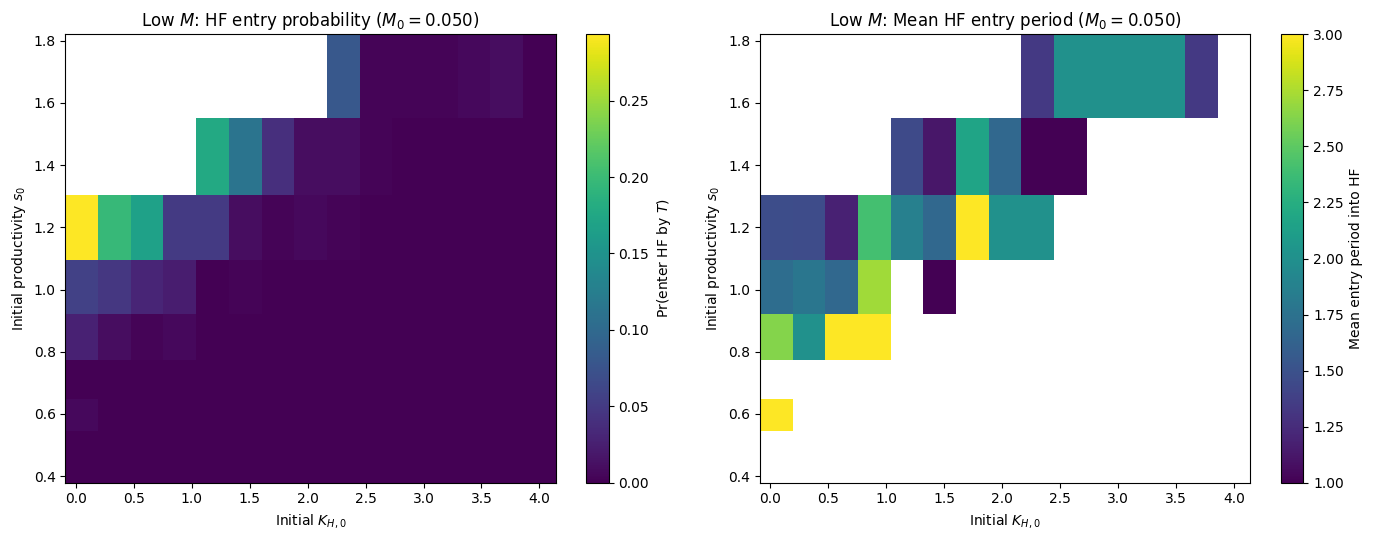

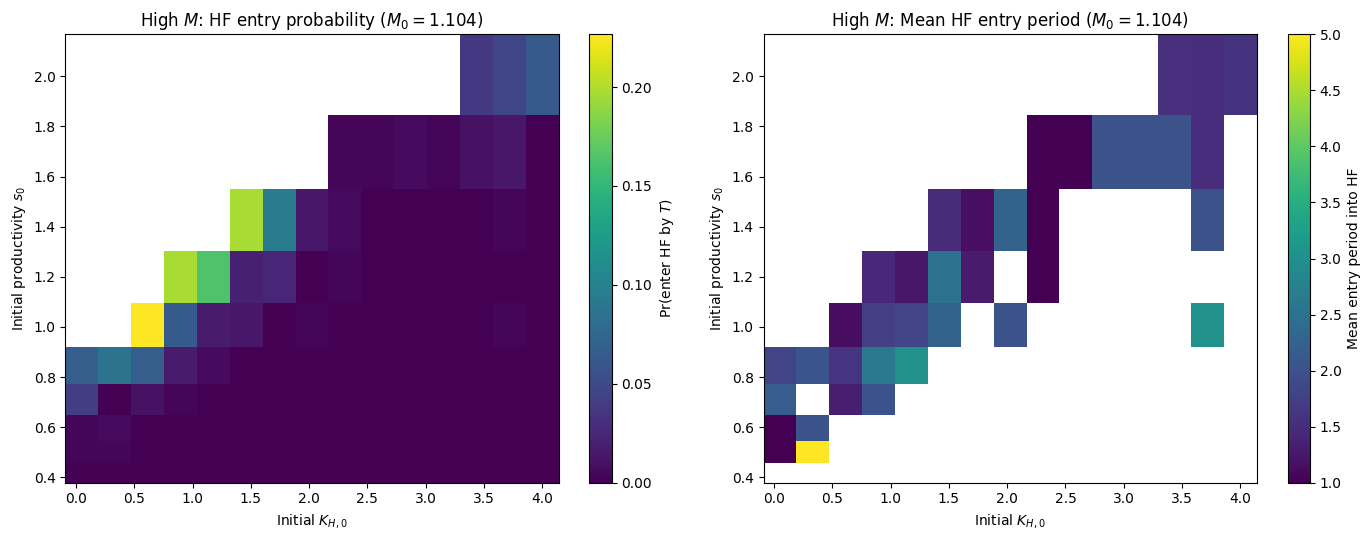

In [105]:
plot_heatmaps_for_one_M(agg_state_df_lowM, fig_title_prefix="Low $M$: ")
plot_heatmaps_for_one_M(agg_state_df_highM, fig_title_prefix="High $M$: ")

### Additional
1. HF cutoff as a function of $M$
2. For each $K_H,M$, record the lowest s at which the chosen mode becomes $HF$



In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, Optional

# 1.HF cutoff for different values of M and K_H
def compute_hf_cutoff_table(
    model_bundle: Dict[str, object],
    period: int = 0,
    prev_mode: str = "X",
    KF_target: float = 0.0,
) -> pd.DataFrame:
    """
    For each (KH, M) pair, compute the lowest productivity s at which
    the policy chooses HF.

    Returns a DataFrame with columns:
        KH, KF, M, hf_cutoff_s, hf_ever_chosen
    """
    KH_grid = model_bundle["KH_grid"]
    KF_grid = model_bundle["KF_grid"]
    M_grid = model_bundle["M_grid"]
    s_grid = model_bundle["s_grid"]
    cfg = model_bundle["cfg"]
    sol = model_bundle["period_solutions"][period]

    pm = cfg.mode_to_index[prev_mode]
    hf_idx = cfg.mode_to_index["HF"]
    j = nearest_index(KF_grid, KF_target)
    KF_used = float(KF_grid[j])

    rows = []

    for i, KH in enumerate(KH_grid):
        for m_idx, M in enumerate(M_grid):
            mode_idx_line = sol["policy_mode"][pm, i, j, m_idx, :]
            hf_mask = np.array(mode_idx_line == hf_idx, dtype=bool)

            if hf_mask.any():
                first_hf_idx = int(np.argmax(hf_mask))
                hf_cutoff_s = float(s_grid[first_hf_idx])
                hf_ever_chosen = 1
            else:
                hf_cutoff_s = np.nan
                hf_ever_chosen = 0

            rows.append({
                "KH": float(KH),
                "KF": KF_used,
                "M": float(M),
                "KH_idx": int(i),
                "M_idx": int(m_idx),
                "hf_cutoff_s": hf_cutoff_s,
                "hf_ever_chosen": hf_ever_chosen,
            })

    return pd.DataFrame(rows)

def plot_hf_cutoff_vs_M(
    cutoff_df: pd.DataFrame,
    KH_targets: tuple[float, ...] = (0.33, 1.46),
    title: Optional[str] = None,
) -> pd.DataFrame:
    """
    Plot the implied HF cutoff s* as a function of M for a few fixed KH values.

    Returns a small DataFrame showing which KH grid points were used.
    """
    fig, ax = plt.subplots(figsize=(8, 5.5))
    chosen_rows = []

    available_KH = np.sort(cutoff_df["KH"].unique())

    for KH_t in KH_targets:
        KH_used = float(available_KH[np.argmin(np.abs(available_KH - KH_t))])
        sub = cutoff_df.loc[cutoff_df["KH"] == KH_used].sort_values("M")

        ax.plot(
            sub["M"],
            sub["hf_cutoff_s"],
            marker="o",
            label=fr"$K_H={KH_used:.2f}$"
        )

        chosen_rows.append({
            "KH_target": KH_t,
            "KH_used": KH_used,
        })

    ax.set_xlabel(r"Technology capital $M$")
    ax.set_ylabel(r"HF cutoff productivity $s^*(K_H,M)$")
    ax.set_title(title or r"Implied HF cutoff as a function of $M$")
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(chosen_rows)


# 2. Minimum s for HF choice as a heatmap over (KH, M)
def make_cutoff_matrix(cutoff_df: pd.DataFrame):
    """
    Build a matrix with:
      rows    = M
      columns = KH
      entries = hf_cutoff_s
    """
    pivot = cutoff_df.pivot(index="M", columns="KH", values="hf_cutoff_s")
    pivot = pivot.sort_index(axis=0).sort_index(axis=1)

    y_vals = pivot.index.to_numpy(dtype=float)    # M
    x_vals = pivot.columns.to_numpy(dtype=float)  # KH
    Z = pivot.to_numpy(dtype=float)

    return x_vals, y_vals, Z


def centers_to_edges(vals: np.ndarray) -> np.ndarray:
    vals = np.asarray(vals, dtype=float)
    if len(vals) < 2:
        raise ValueError("Need at least 2 grid points to construct edges.")
    mids = 0.5 * (vals[:-1] + vals[1:])
    first = vals[0] - 0.5 * (vals[1] - vals[0])
    last = vals[-1] + 0.5 * (vals[-1] - vals[-2])
    return np.concatenate([[first], mids, [last]])


def plot_hf_cutoff_heatmap(
    cutoff_df: pd.DataFrame,
    title: str = r"Implied HF cutoff $s^*(K_H,M)$",
) -> None:
    x_vals, y_vals, Z = make_cutoff_matrix(cutoff_df)

    Z_masked = np.ma.masked_invalid(Z)
    x_edges = centers_to_edges(x_vals)
    y_edges = centers_to_edges(y_vals)

    fig, ax = plt.subplots(figsize=(8, 5.8))
    pcm = ax.pcolormesh(
        x_edges,
        y_edges,
        Z_masked,
        shading="auto"
    )

    ax.set_xlabel(r"Home capital $K_H$")
    ax.set_ylabel(r"Technology capital $M$")
    ax.set_title(title)

    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(r"Lowest $s$ such that policy chooses HF")

    plt.tight_layout()
    plt.show()

# 3. 
def plot_hf_cutoff_vs_KH(
        
    cutoff_df: pd.DataFrame,
    M_targets: tuple[float, ...] = (0.05, 1.10),
    title: Optional[str] = None,
) -> pd.DataFrame:
    """
    Plot the implied HF cutoff s* as a function of KH for a few fixed M values.
    """
    fig, ax = plt.subplots(figsize=(8, 5.5))
    chosen_rows = []

    available_M = np.sort(cutoff_df["M"].unique())

    for M_t in M_targets:
        M_used = float(available_M[np.argmin(np.abs(available_M - M_t))])
        sub = cutoff_df.loc[cutoff_df["M"] == M_used].sort_values("KH")

        ax.plot(
            sub["KH"],
            sub["hf_cutoff_s"],
            marker="o",
            label=fr"$M={M_used:.2f}$"
        )

        chosen_rows.append({
            "M_target": M_t,
            "M_used": M_used,
        })

    ax.set_xlabel(r"Home capital $K_H$")
    ax.set_ylabel(r"HF cutoff productivity $s^*(K_H,M)$")
    ax.set_title(title or r"Implied HF cutoff as a function of $K_H$")
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(chosen_rows)

# 

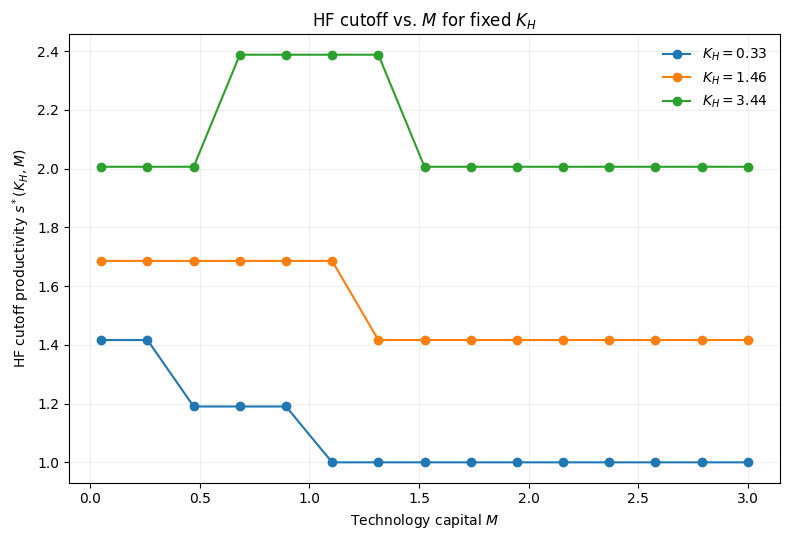

   KH_target   KH_used
0       0.33  0.332143
1       1.46  1.460714
2       3.50  3.435714


In [91]:
cutoff_df = compute_hf_cutoff_table(
    model_bundle=bundle,
    period=0,
    prev_mode="X",
    KF_target=0.0,
)

chosen_KH_df = plot_hf_cutoff_vs_M(
    cutoff_df,
    KH_targets=(0.33, 1.46, 3.5),
    title=r"HF cutoff vs. $M$ for fixed $K_H$"
)

print(chosen_KH_df)

1. For higher levels of K_H the cutoff to become a MNE is higher. 
2. Increasing M decreases the productivity cutoff. 

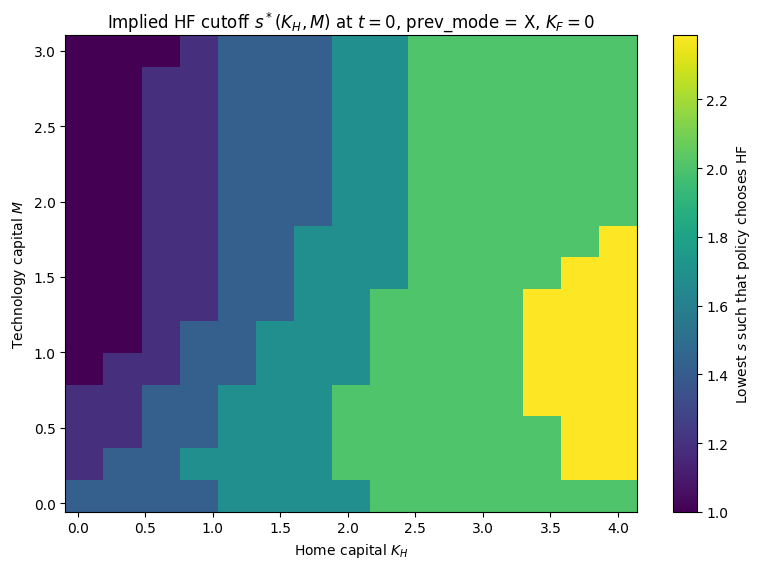

In [92]:
plot_hf_cutoff_heatmap(
    cutoff_df,
    title=r"Implied HF cutoff $s^*(K_H,M)$ at $t=0$, prev_mode = X, $K_F=0$"
)

Fix $M$: Exporters which have entered with a higher inital capitals stock need a higher productivity cutoff to become a MNE. THis is because exporting is alrady profitable compared to lower levels of $K_H$

Fix $K_H$: for most values increasing M lower the productivity cutoff need to become a MNE 

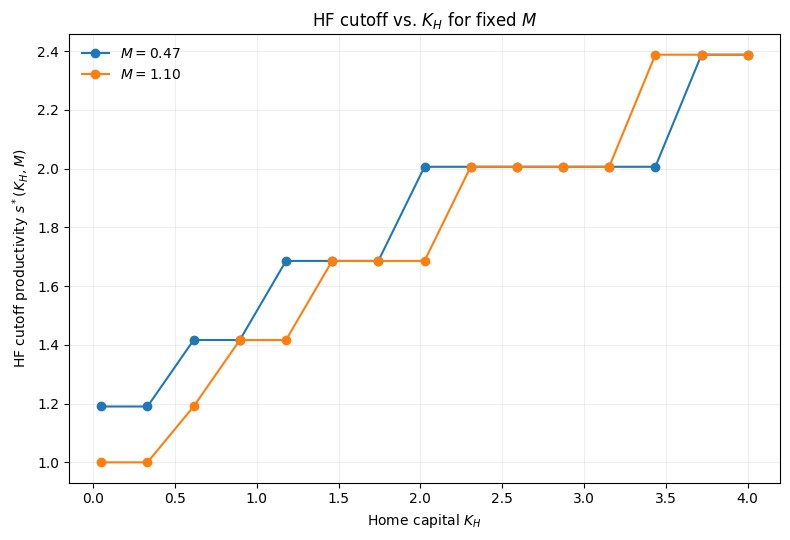

   M_target    M_used
0       0.5  0.471429
1       1.1  1.103571


In [93]:
chosen_M_df = plot_hf_cutoff_vs_KH(
    cutoff_df,
    M_targets=(0.5, 1.10),
    title=r"HF cutoff vs. $K_H$ for fixed $M$"
)

print(chosen_M_df)

###  Pick 3 inital states
1. Low probability of entering HF
2. 50% probability of enter HF
3. High probability of entering HF 

In [94]:
def pick_representative_states(
    agg_state_df: pd.DataFrame,
    targets=(0.05, 0.15, 0.25),
    labels=("low", "middle", "high"),
) -> pd.DataFrame:
    """
    Pick representative initial states based on target HF-entry probabilities.

    Assumes agg_state_df is already filtered to one M slice if that is what you want.
    """
    if len(targets) != len(labels):
        raise ValueError("targets and labels must have the same length.")

    df = agg_state_df.copy()
    chosen_rows = []
    used_state_ids = set()

    for target, label in zip(targets, labels):
        cand = df.loc[~df["state_id"].isin(used_state_ids)].copy()
        cand["distance_to_target"] = (cand["hf_share_ever"] - target).abs()

        # tie-break toward cleaner / lower states
        sort_cols = ["distance_to_target", "s0", "KH0"]
        ascending = [True, True, True]

        if "M0" in cand.columns:
            sort_cols.append("M0")
            ascending.append(True)

        cand = cand.sort_values(sort_cols, ascending=ascending)

        row = cand.iloc[0].copy()
        row["target_prob"] = target
        row["label"] = label

        chosen_rows.append(row)
        used_state_ids.add(int(row["state_id"]))

    out = pd.DataFrame(chosen_rows).reset_index(drop=True)

    keep_cols = [
        "label",
        "target_prob",
        "state_id",
        "s0_idx",
        "s0",
        "KH0",
        "KF0",
        "M0",
        "hf_share_ever",
        "mean_entry_period",
        "stay_x_share",
    ]

    if "M0_idx" in out.columns:
        keep_cols.append("M0_idx")
    if "initial_profit_X" in out.columns:
        keep_cols.append("initial_profit_X")
    if "export_premium" in out.columns:
        keep_cols.append("export_premium")

    keep_cols = [c for c in keep_cols if c in out.columns]
    return out[keep_cols]

In [95]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from typing import Dict

def simulate_selected_states(
    model_bundle: Dict[str, object],
    selected_states: pd.DataFrame,
    N: int = 300,
    stochastic: bool = True,
    initial_prev_mode: str = "X",
    seed: int = 123,
) -> dict:
    """
    Simulate N firms from each selected initial state.
    Returns a dict keyed by label.

    Expected columns in selected_states:
        label, KH0, KF0, M0
    Preferably also:
        s0_idx
    """
    out = {}

    for idx, row in selected_states.iterrows():
        label = str(row["label"])

        if "s0_idx" in row.index:
            s0_idx = int(row["s0_idx"])
        else:
            s0_idx = int(nearest_index(model_bundle["s_grid"], float(row["s0"])))

        paths = simulate_many_paths(
            model_bundle=model_bundle,
            KH0=float(row["KH0"]),
            KF0=float(row["KF0"]),
            M0=float(row["M0"]),
            s0_idx=s0_idx,
            n_firms=N,
            initial_prev_mode=initial_prev_mode,
            stochastic=stochastic,
            seed=seed + idx,
        )

        out[label] = {
            "state_info": row.to_dict(),
            "paths": paths,
        }

    return out


def plot_selected_state_figures(sim_selected: dict) -> None:
    """
    Create:
      1. one 1x3 figure for mean investment paths (i_H, i_F, i_M)
      2. one 4x1 figure for mean capital/share paths (K_H, K_F, M, HF share)
    """

    # -----------------------------
    # Figure 1: Investment paths (1x3)
    # -----------------------------
    fig1, axes1 = plt.subplots(1, 3, figsize=(16, 4.8))

    for label, obj in sim_selected.items():
        paths = obj["paths"]
        row = obj["state_info"]

        arr_iH = np.array([p["iH_path"] for p in paths], dtype=float)
        arr_iF = np.array([p["iF_path"] for p in paths], dtype=float)
        arr_iM = np.array([p["iM_path"] for p in paths], dtype=float)

        mean_iH = arr_iH.mean(axis=0)
        mean_iF = arr_iF.mean(axis=0)
        mean_iM = arr_iM.mean(axis=0)

        legend_label = (
            f"{label}: s0={row['s0']:.2f}, KH0={row['KH0']:.2f}, "
            f"M0={row['M0']:.2f}"
        )

        axes1[0].plot(range(len(mean_iH)), mean_iH, marker="o", label=legend_label)
        axes1[1].plot(range(len(mean_iF)), mean_iF, marker="o", label=legend_label)
        axes1[2].plot(range(len(mean_iM)), mean_iM, marker="o", label=legend_label)

    axes1[0].set_xlabel("Period")
    axes1[0].set_ylabel(r"Mean $i_H$")
    axes1[0].set_title(r"Home investment $i_H$")

    axes1[1].set_xlabel("Period")
    axes1[1].set_ylabel(r"Mean $i_F$")
    axes1[1].set_title(r"Foreign investment $i_F$")

    axes1[2].set_xlabel("Period")
    axes1[2].set_ylabel(r"Mean $i_M$")
    axes1[2].set_title(r"Technology investment $i_M$")

    handles1, labels1 = axes1[0].get_legend_handles_labels()
    fig1.legend(
        handles1, labels1,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.08),
        ncol=min(3, len(labels1)),
        frameon=False
    )
    fig1.suptitle("Investment paths by selected initial state", y=1.03)
    plt.tight_layout(rect=[0, 0.10, 1, 0.95])
    plt.show()

    # -----------------------------
    # Figure 2: Capital + HF share (4x1)
    # -----------------------------
    fig2, axes2 = plt.subplots(4, 1, figsize=(8.5, 14), sharex=False)

    for label, obj in sim_selected.items():
        paths = obj["paths"]
        row = obj["state_info"]

        arr_KH = np.array([p["KH_path"] for p in paths], dtype=float)
        arr_KF = np.array([p["KF_path"] for p in paths], dtype=float)
        arr_M = np.array([p["M_path"] for p in paths], dtype=float)
        hf_share_t = np.array([
            [1.0 if m == "HF" else 0.0 for m in p["mode_path"]]
            for p in paths
        ]).mean(axis=0)

        mean_KH = arr_KH.mean(axis=0)
        mean_KF = arr_KF.mean(axis=0)
        mean_M = arr_M.mean(axis=0)

        legend_label = (
            f"{label}: s0={row['s0']:.2f}, KH0={row['KH0']:.2f}, "
            f"M0={row['M0']:.2f}"
        )

        axes2[0].plot(range(len(mean_KH)), mean_KH, marker="o", label=legend_label)
        axes2[1].plot(range(len(mean_KF)), mean_KF, marker="o", label=legend_label)
        axes2[2].plot(range(len(mean_M)), mean_M, marker="o", label=legend_label)
        axes2[3].plot(range(len(hf_share_t)), hf_share_t, marker="o", label=legend_label)

    axes2[0].set_xlabel("Period")
    axes2[0].set_ylabel(r"Mean $K_H$")
    axes2[0].set_title(r"Home capital $K_H$")

    axes2[1].set_xlabel("Period")
    axes2[1].set_ylabel(r"Mean $K_F$")
    axes2[1].set_title(r"Foreign capital $K_F$")

    axes2[2].set_xlabel("Period")
    axes2[2].set_ylabel(r"Mean $M$")
    axes2[2].set_title(r"Technology capital $M$")

    axes2[3].set_xlabel("Period")
    axes2[3].set_ylabel("Share in HF")
    axes2[3].set_title("HF share")

    handles2, labels2 = axes2[0].get_legend_handles_labels()
    fig2.legend(
        handles2, labels2,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=min(3, len(labels2)),
        frameon=False
    )
    fig2.suptitle("Capital paths and HF transition by selected initial state", y=0.995)
    plt.tight_layout(rect=[0, 0.05, 1, 0.98])
    plt.show()

    label  target_prob  state_id  s0_idx        s0       KH0  KF0        M0  \
0     low         0.05     492.0     9.0  2.006631  3.717857  0.0  1.103571   
1  middle         0.15     463.0     6.0  1.190192  1.178571  0.0  1.103571   
2    high         0.25     449.0     5.0  1.000000  0.614286  0.0  1.103571   

   hf_share_ever  mean_entry_period  stay_x_share  M0_idx  initial_profit_X  \
0       0.046667           1.500000      0.953333     5.0          2.280082   
1       0.163333           1.244898      0.836667     5.0          0.435657   
2       0.226667           1.132353      0.773333     5.0          0.200468   

   export_premium  
0        0.754990  
1        0.144178  
2        0.066291  


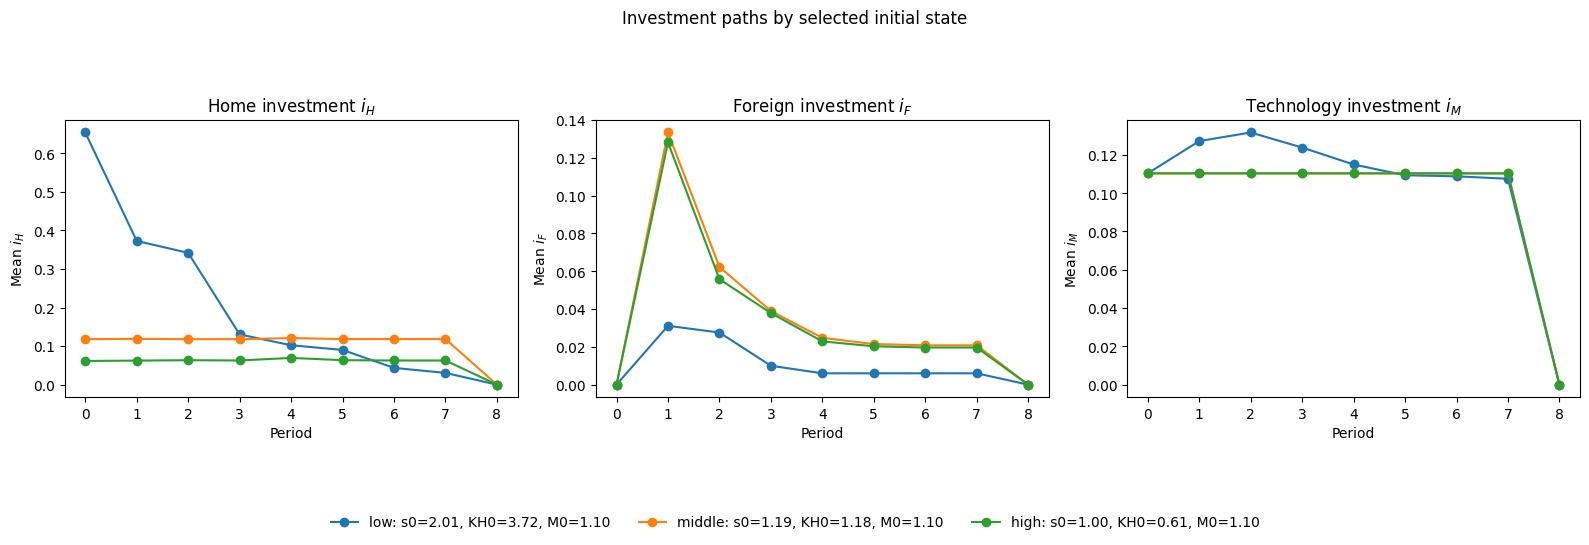

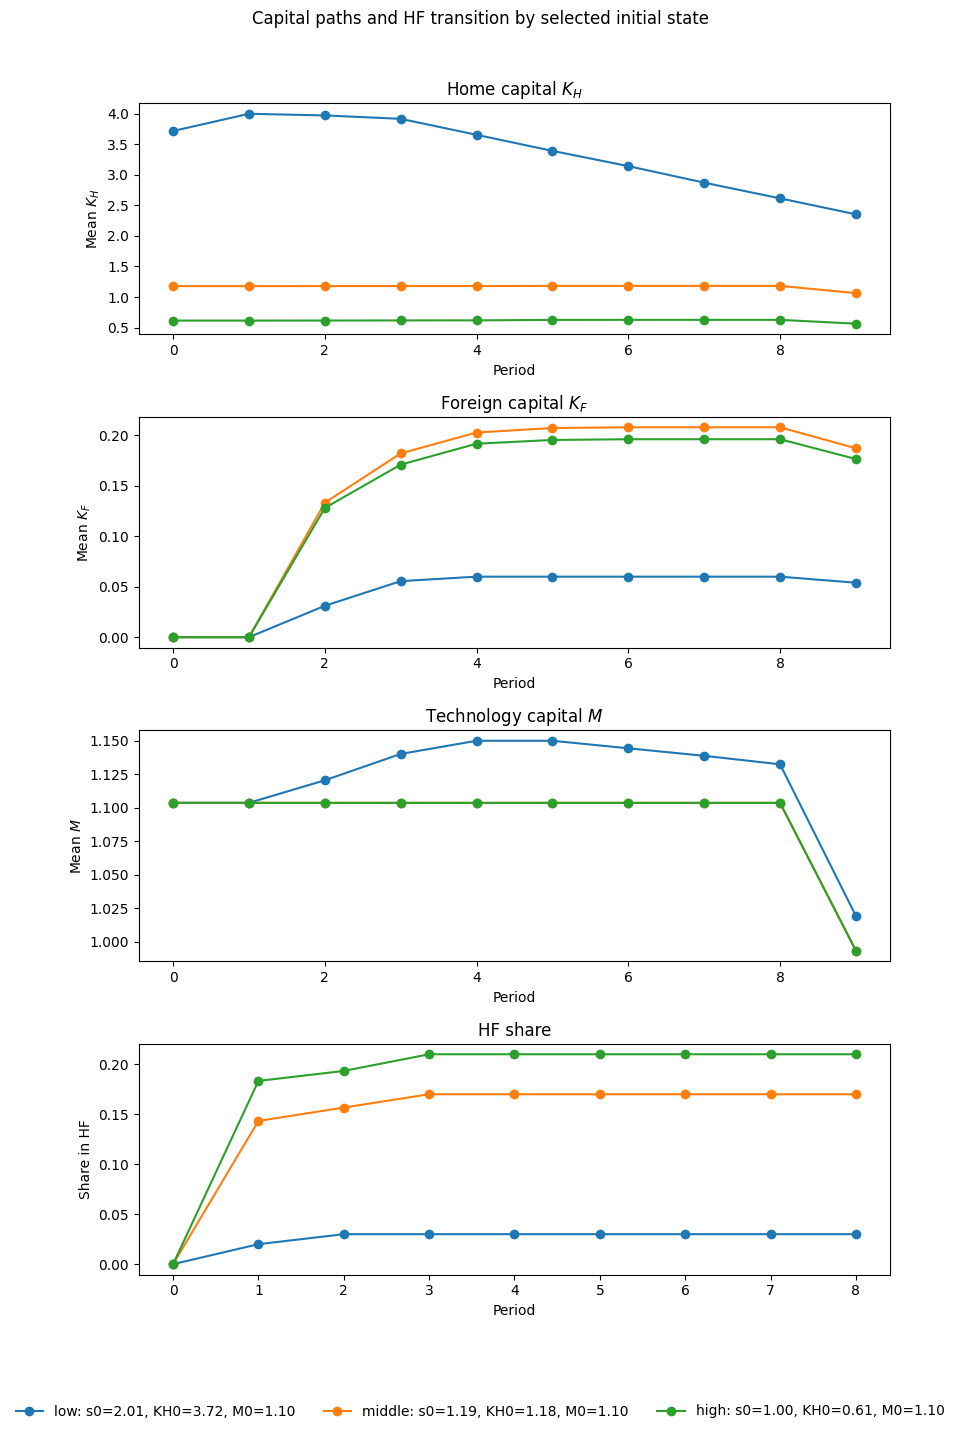

In [103]:
selected_states = pick_representative_states(agg_state_df_highM)
print(selected_states)

sim_selected = simulate_selected_states(
    model_bundle= bundle,
    selected_states=selected_states,
    N=300,
    stochastic=True,
    initial_prev_mode="X",
    seed=123,
)

plot_selected_state_figures(sim_selected)

    label  target_prob  state_id  s0_idx        s0       KH0  KF0    M0  \
0     low         0.05      93.0     6.0  1.190192  0.896429  0.0  0.05   
1  middle         0.15      92.0     6.0  1.190192  0.614286  0.0  0.05   
2    high         0.25      90.0     6.0  1.190192  0.050000  0.0  0.05   

   hf_share_ever  mean_entry_period  stay_x_share  M0_idx  initial_profit_X  \
0       0.050000           2.400000      0.950000     0.0          0.190874   
1       0.166667           1.180000      0.833333     0.0          0.146932   
2       0.293333           1.465909      0.706667     0.0          0.003857   

   export_premium  
0        0.063114  
1        0.048561  
2        0.001180  


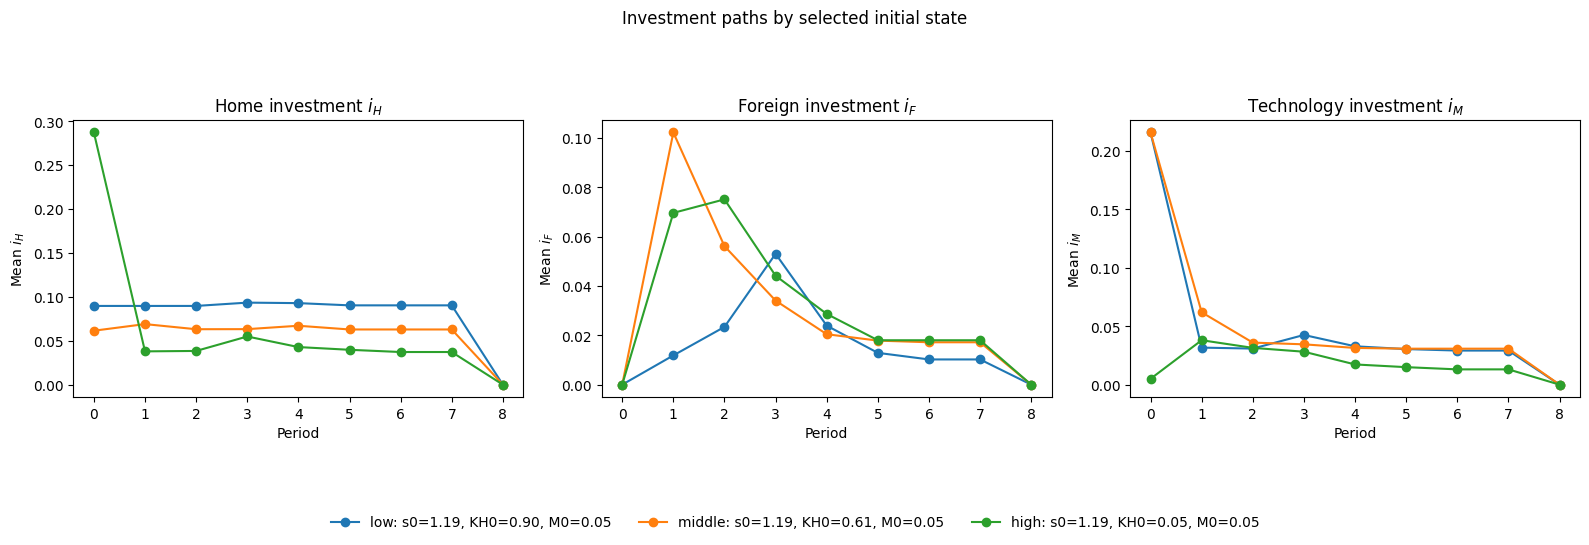

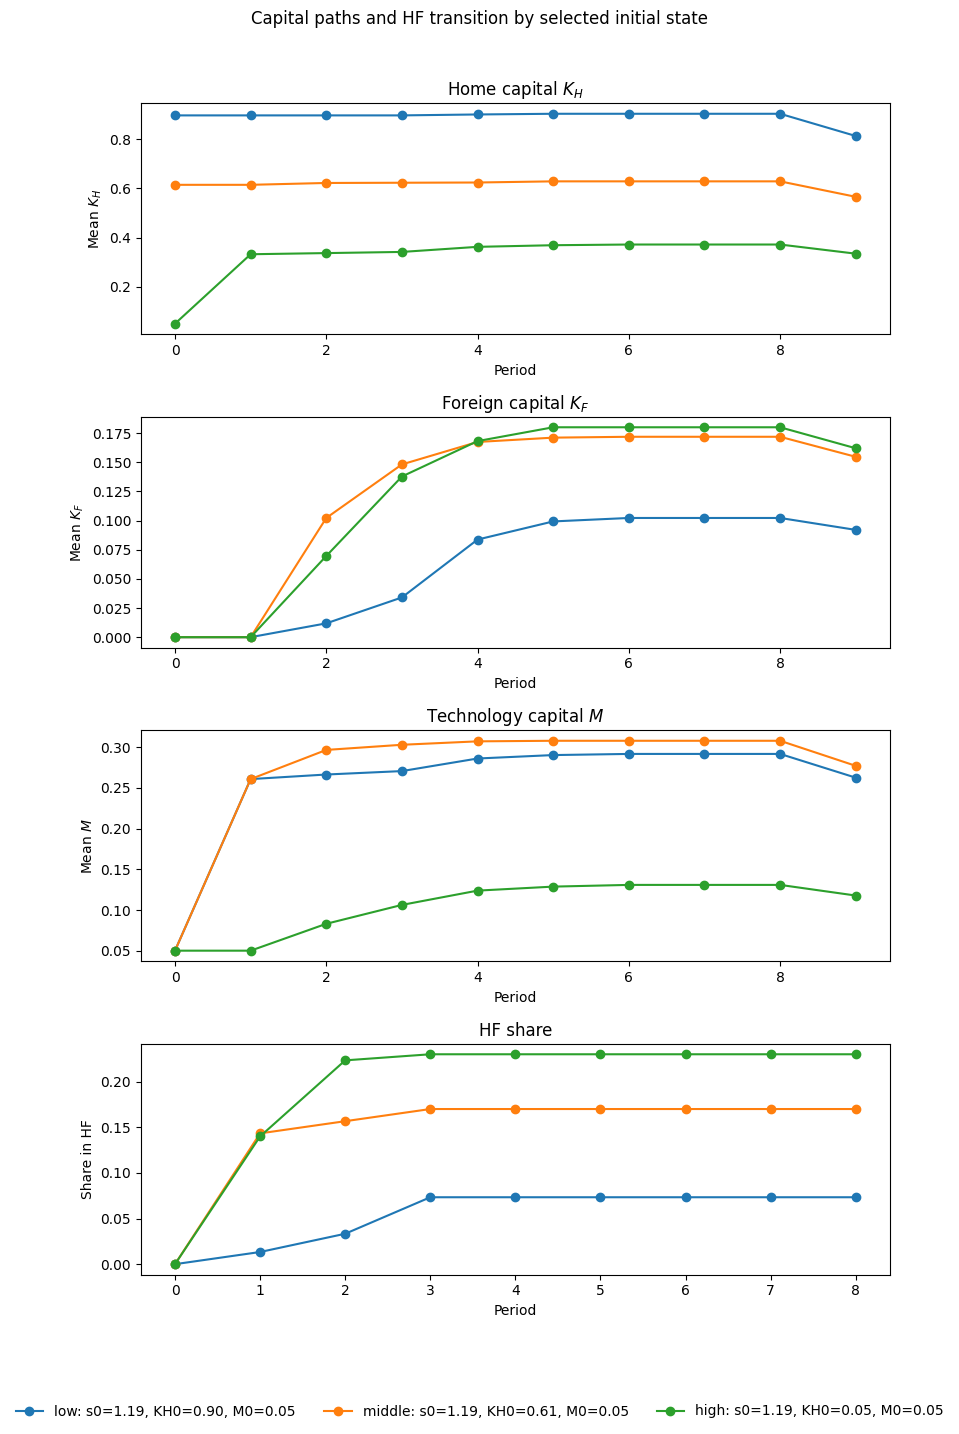

In [102]:
selected_states = pick_representative_states(agg_state_df_lowM)
print(selected_states)

sim_selected = simulate_selected_states(
    model_bundle= bundle,
    selected_states=selected_states,
    N=300,
    stochastic=True,
    initial_prev_mode="X",
    seed=123,
)

plot_selected_state_figures(sim_selected)

## Distributions 

In [114]:
import numpy as np
import pandas as pd

def build_entry_event_investment_df(long_df: pd.DataFrame) -> pd.DataFrame:
    """
    Build an event-time panel around first HF entry.

    Keeps only firms that ever enter HF and only the three event times:
        rel_t = -1, 0, +1

    Returns a long DataFrame with columns:
        state_id, firm_id, first_hf_t, t, rel_t, event_label,
        investment_type, investment_value
    """
    df = long_df.copy()

    # First HF entry period for each firm
    first_hf = (
        df.loc[df["mode_t"] == "HF"]
        .groupby(["state_id", "firm_id"], as_index=False)["t"]
        .min()
        .rename(columns={"t": "first_hf_t"})
    )

    # Keep only firms that ever enter HF
    df = df.merge(first_hf, on=["state_id", "firm_id"], how="inner")

    # Event time relative to first HF entry
    df["rel_t"] = df["t"] - df["first_hf_t"]

    # Keep one period before, at entry, and one period after
    df = df[df["rel_t"].isin([-2, -1, 0, 1, 2])].copy()

    # Nice labels
    label_map = {
        -2: "t-2",
        -1: "t-1",
         0: "entry",
         1: "t+1",
         2: "t+2",
    }
    df["event_label"] = df["rel_t"].map(label_map)

    # Reshape investments to long format
    event_df = df.melt(
        id_vars=[
            "state_id", "firm_id", "t", "first_hf_t", "rel_t", "event_label",
            "KH0", "KF0", "M0", "s0_idx", "s0"
        ],
        value_vars=["iH_t", "iF_t", "iM_t"],
        var_name="investment_type",
        value_name="investment_value"
    )

    # Cleaner names
    type_map = {
        "iH_t": "i_H",
        "iF_t": "i_F",
        "iM_t": "i_M",
    }
    event_df["investment_type"] = event_df["investment_type"].map(type_map)

    return event_df.reset_index(drop=True)

import matplotlib.pyplot as plt

def plot_entry_event_investment_distributions(
    event_df: pd.DataFrame,
    figsize=(15, 4.8),
    showfliers=False,
) -> None:
    """
    Plot investment distributions at t-1, entry, and t+1
    for i_H, i_F, and i_M.
    """
    order = ["t-1", "entry", "t+1"]
    inv_types = ["i_H", "i_F", "i_M"]
    titles = {
        "i_H": r"Home investment $i_H$",
        "i_F": r"Foreign investment $i_F$",
        "i_M": r"Technology investment $i_M$",
    }

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    for ax, inv in zip(axes, inv_types):
        sub = event_df[event_df["investment_type"] == inv].copy()

        data = [
            sub.loc[sub["event_label"] == lab, "investment_value"].dropna().to_numpy()
            for lab in order
        ]

        ax.boxplot(
            data,
            labels=order,
            showfliers=showfliers,
        )
        ax.set_title(titles[inv])
        ax.set_xlabel("Event time")
        ax.set_ylabel("Investment")

    plt.tight_layout()
    plt.show()



/var/folders/mz/9j0q2hw52gn0z79drwg1nbsw0000gn/T/ipykernel_64713/2364780352.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/mz/9j0q2hw52gn0z79drwg1nbsw0000gn/T/ipykernel_64713/2364780352.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/mz/9j0q2hw52gn0z79drwg1nbsw0000gn/T/ipykernel_64713/2364780352.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


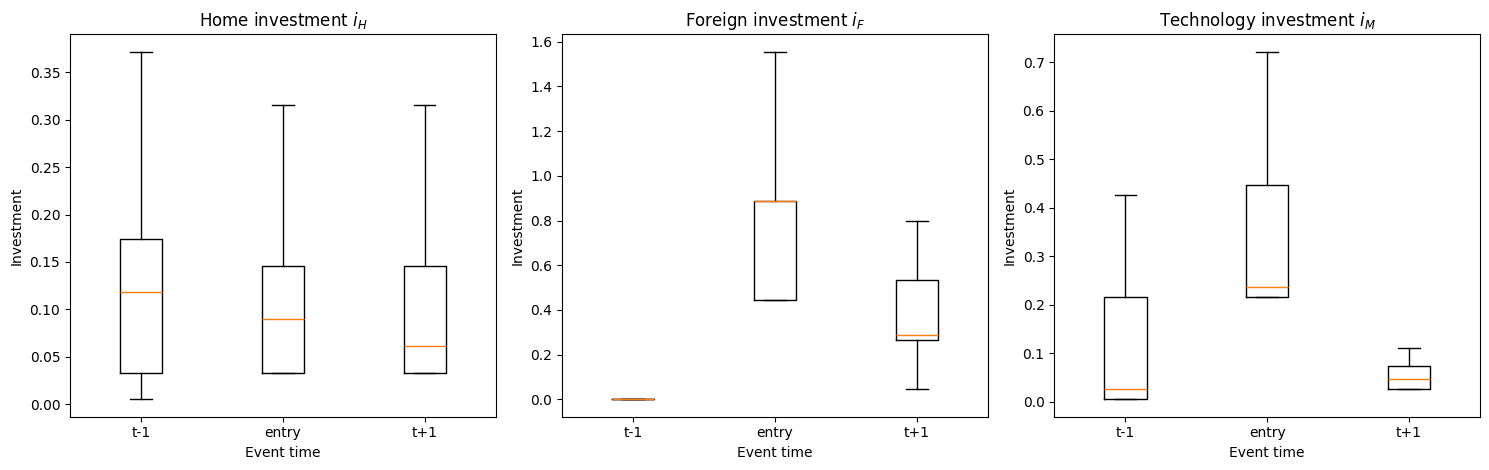

/var/folders/mz/9j0q2hw52gn0z79drwg1nbsw0000gn/T/ipykernel_64713/2364780352.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/mz/9j0q2hw52gn0z79drwg1nbsw0000gn/T/ipykernel_64713/2364780352.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/mz/9j0q2hw52gn0z79drwg1nbsw0000gn/T/ipykernel_64713/2364780352.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


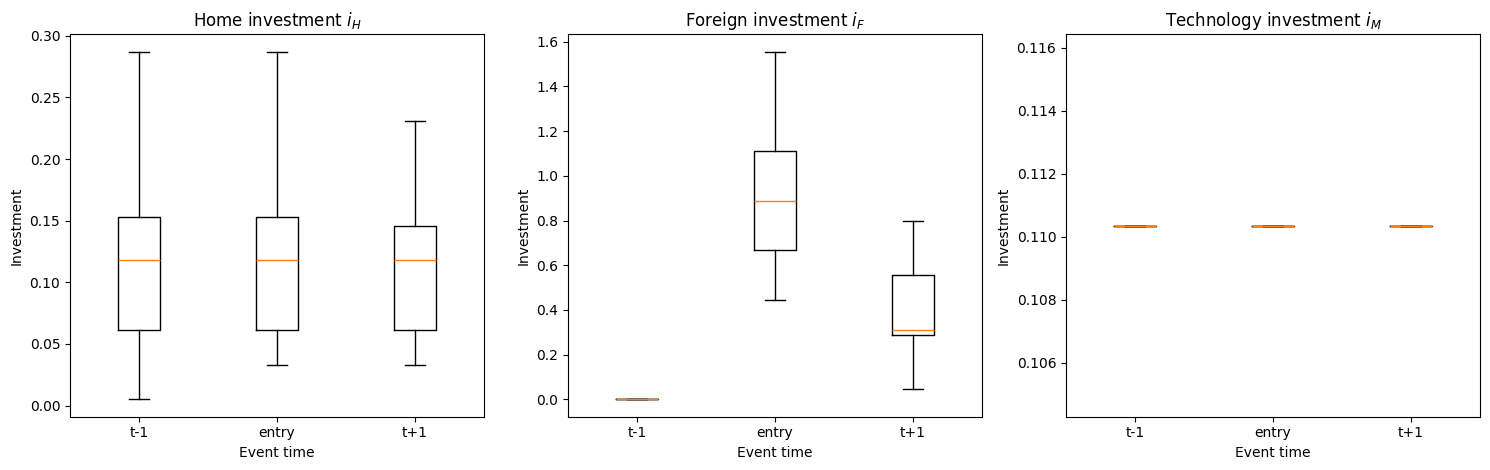

In [115]:
entry_event_df = build_entry_event_investment_df(long_df_lowM)
plot_entry_event_investment_distributions(entry_event_df)

entry_event_df = build_entry_event_investment_df(long_df_highM)
plot_entry_event_investment_distributions(entry_event_df)

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def build_final_period_cross_section(long_df: pd.DataFrame) -> pd.DataFrame:
    """
    Keep the last decision-period observation for each firm.

    Output has one row per firm, with the final regime given by mode_t.
    """
    df = long_df.copy()

    idx = (
        df.groupby(["state_id", "firm_id"])["t"]
        .idxmax()
        .to_numpy()
    )

    final_df = df.loc[idx].copy().reset_index(drop=True)
    final_df["final_regime"] = final_df["mode_t"]

    return final_df


def _ordered_regimes(regimes):
    preferred = ["X", "HF"]
    present = [r for r in preferred if r in regimes]
    leftovers = [r for r in regimes if r not in preferred]
    return present + sorted(leftovers)


def plot_final_capital_distributions_by_regime(
    final_df: pd.DataFrame,
    use_tp1_stocks: bool = False,
    showfliers: bool = False,
    figsize=(15, 4.8),
) -> None:
    """
    Plot distributions of final capital stocks by final regime.

    If use_tp1_stocks=False:
        uses KH_t, KF_t, M_t from the last decision period.
    If use_tp1_stocks=True:
        uses KH_tp1, KF_tp1, M_tp1 (post-investment next-period stocks).
    """
    regimes = _ordered_regimes(final_df["final_regime"].dropna().unique().tolist())
    if len(regimes) == 0:
        raise ValueError("No regimes found in final_df.")

    if use_tp1_stocks:
        cols = [("KH_tp1", r"$K_H$"), ("KF_tp1", r"$K_F$"), ("M_tp1", r"$M$")]
        title_suffix = " (post-investment stocks)"
    else:
        cols = [("KH_t", r"$K_H$"), ("KF_t", r"$K_F$"), ("M_t", r"$M$")]
        title_suffix = " (last decision-period stocks)"

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    for ax, (col, label) in zip(axes, cols):
        data = [
            final_df.loc[final_df["final_regime"] == reg, col].dropna().to_numpy()
            for reg in regimes
        ]

        ax.boxplot(
            data,
            labels=regimes,
            showfliers=showfliers,
        )
        ax.set_xlabel("Final regime")
        ax.set_ylabel(label)
        ax.set_title(f"Distribution of {label}")

    fig.suptitle(f"Final capital distributions by regime{title_suffix}", y=1.02)
    plt.tight_layout()
    plt.show()


def plot_final_productivity_distribution_by_regime(
    final_df: pd.DataFrame,
    showfliers: bool = False,
    figsize=(6.5, 4.8),
) -> None:
    """
    Plot the distribution of final-period productivity s_t by final regime.
    """
    regimes = _ordered_regimes(final_df["final_regime"].dropna().unique().tolist())
    if len(regimes) == 0:
        raise ValueError("No regimes found in final_df.")

    fig, ax = plt.subplots(1, 1, figsize=figsize)

    data = [
        final_df.loc[final_df["final_regime"] == reg, "s_t"].dropna().to_numpy()
        for reg in regimes
    ]

    ax.boxplot(
        data,
        labels=regimes,
        showfliers=showfliers,
    )
    ax.set_xlabel("Final regime")
    ax.set_ylabel(r"Final productivity $s_t$")
    ax.set_title(r"Distribution of final productivity by regime")

    plt.tight_layout()
    plt.show()

/var/folders/mz/9j0q2hw52gn0z79drwg1nbsw0000gn/T/ipykernel_64713/3673193435.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/mz/9j0q2hw52gn0z79drwg1nbsw0000gn/T/ipykernel_64713/3673193435.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/mz/9j0q2hw52gn0z79drwg1nbsw0000gn/T/ipykernel_64713/3673193435.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


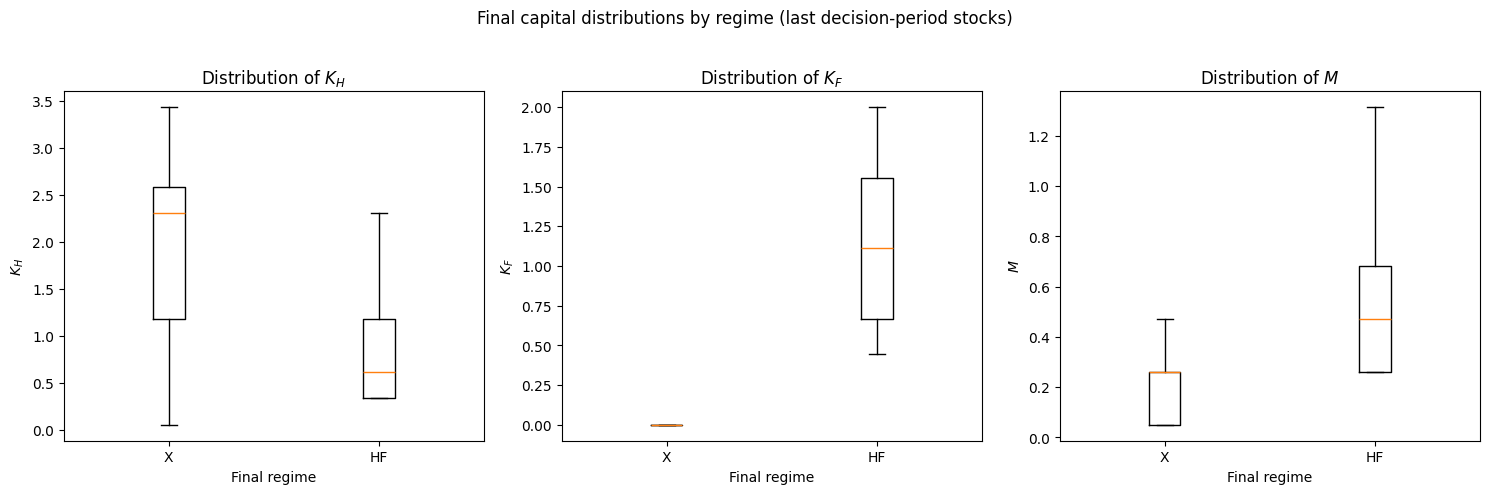

/var/folders/mz/9j0q2hw52gn0z79drwg1nbsw0000gn/T/ipykernel_64713/3673193435.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


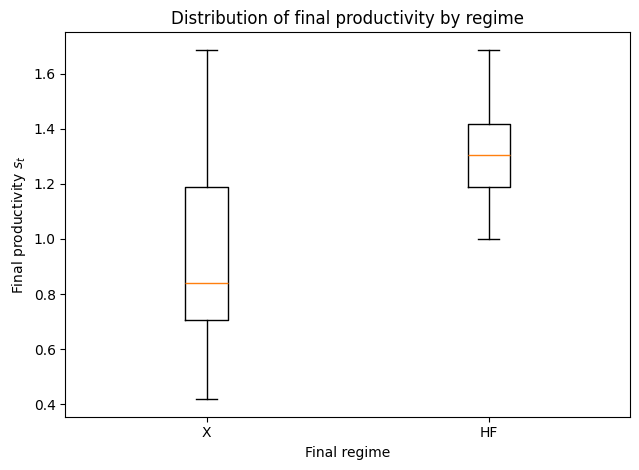

In [111]:
final_df = build_final_period_cross_section(long_df_lowM)

plot_final_capital_distributions_by_regime(
    final_df,
    use_tp1_stocks=False,   # aligned with final regime in last decision period
    showfliers=False,
)

plot_final_productivity_distribution_by_regime(
    final_df,
    showfliers=False,
)